# Rossmann Retail Sales Forecasting & FP&A Analytics
## 02 — Exploratory Data Analysis

### Phase objective

This notebook begins the exploratory analysis of the Rossmann historical data.

The first block does **not** analyse sales patterns yet. It prepares and validates the merged analytical dataset so that later charts and conclusions are based on a reliable structure.

### First-block scope

- Load the original train and store files
- Convert `Date` to datetime
- Merge daily sales with store attributes
- Validate that the merge does not duplicate or lose rows
- Create calendar variables for descriptive analysis
- Confirm the final analytical grain
- Summarise store-level history coverage
- Reconfirm the relationship between `Open` and zero sales

> Stop after the final cell and review the outputs before continuing to the sales-distribution and seasonality analysis.

## 1. Imports and project paths

The notebook uses the same project-root detection approach as the data-audit notebook. This keeps the workflow reproducible whether Jupyter starts in the repository root or in the `notebooks/` folder.

In [1]:
from pathlib import Path
import platform

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Python: 3.11.15
pandas: 2.3.3
NumPy: 2.4.6


In [2]:
def find_project_root(start_path: Path) -> Path:
    """Return the nearest parent containing the expected project folders."""
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Confirm that the data/ and notebooks/ folders exist."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data folder: {RAW_DATA_DIR}")

Project root: C:\Users\koldo\Desktop\Máster de DATA Science con IA\PROYECTO\rossmann-sales-forecasting
Raw data folder: C:\Users\koldo\Desktop\Máster de DATA Science con IA\PROYECTO\rossmann-sales-forecasting\data\raw


## 2. Load the historical and store-master data

Only `train.csv` and `store.csv` are needed for the first EDA block.

`test.csv` will be analysed later when we compare the historical and forecast populations.

In [3]:
train_path = RAW_DATA_DIR / "train.csv"
store_path = RAW_DATA_DIR / "store.csv"

for path in [train_path, store_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

train = pd.read_csv(train_path, low_memory=False)
store = pd.read_csv(store_path, low_memory=False)

print(f"train shape: {train.shape}")
print(f"store shape: {store.shape}")

train shape: (1017209, 9)
store shape: (1115, 10)


## 3. Convert the date and create the analytical dataset

The original raw DataFrames remain unchanged.

The merge uses `validate="many_to_one"` because:

- `train` contains many dates for each store.
- `store` must contain exactly one row per store.

If the store master contained duplicate store identifiers, pandas would raise an error instead of silently multiplying rows.

In [5]:
train_eda = train.copy()
store_eda = store.copy()

train_eda["Date"] = pd.to_datetime(train_eda["Date"], errors="raise")

rows_before_merge = len(train_eda)

train_eda = train_eda.merge(
    store_eda,
    on="Store",
    how="left",
    validate="many_to_one",
    indicator=True,
)

merge_summary = (
    train_eda["_merge"]
    .value_counts(dropna=False)
    .rename_axis("merge_status")
    .reset_index(name="rows")
)

rows_after_merge = len(train_eda)
unmatched_rows = int((train_eda["_merge"] != "both").sum())

print(f"Rows before merge: {rows_before_merge:,}")
print(f"Rows after merge:  {rows_after_merge:,}")
print(f"Unmatched rows:    {unmatched_rows:,}")

display(merge_summary)

assert rows_before_merge == rows_after_merge, "The merge changed the row count."
assert unmatched_rows == 0, "Some daily records have no matching store-master row."

train_eda = train_eda.drop(columns="_merge")

Rows before merge: 1,017,209
Rows after merge:  1,017,209
Unmatched rows:    0


,merge_status,rows
0,both,1017209
1,left_only,0
2,right_only,0


## 4. Create calendar variables for descriptive analysis

These variables are derived only from the date, so they do not introduce future information.

They are created now for EDA. Their later use as model features will still be assessed separately.

In [6]:
train_eda["Year"] = train_eda["Date"].dt.year
train_eda["Quarter"] = train_eda["Date"].dt.quarter
train_eda["Month"] = train_eda["Date"].dt.month
train_eda["MonthName"] = train_eda["Date"].dt.month_name().str.slice(stop=3)
train_eda["ISOWeek"] = train_eda["Date"].dt.isocalendar().week.astype("int16")
train_eda["Day"] = train_eda["Date"].dt.day
train_eda["IsWeekend"] = train_eda["DayOfWeek"].isin([6, 7]).astype("int8")
train_eda["IsMonthStart"] = train_eda["Date"].dt.is_month_start.astype("int8")
train_eda["IsMonthEnd"] = train_eda["Date"].dt.is_month_end.astype("int8")

calendar_columns = [
    "Date",
    "Year",
    "Quarter",
    "Month",
    "MonthName",
    "ISOWeek",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "IsMonthStart",
    "IsMonthEnd",
]

display(train_eda[calendar_columns].head())

,Date,Year,Quarter,Month,MonthName,ISOWeek,Day,DayOfWeek,IsWeekend,IsMonthStart,IsMonthEnd
0,2015-07-31,2015,3,7,Jul,31,31,5,0,0,1
1,2015-07-31,2015,3,7,Jul,31,31,5,0,0,1
2,2015-07-31,2015,3,7,Jul,31,31,5,0,0,1
3,2015-07-31,2015,3,7,Jul,31,31,5,0,0,1
4,2015-07-31,2015,3,7,Jul,31,31,5,0,0,1


## 5. Validate the analytical grain and overall structure

The expected grain remains one row per `Store` and `Date` after the merge and calendar enrichment.

In [7]:
analytical_overview = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Columns",
            "Unique stores",
            "Unique dates",
            "Minimum date",
            "Maximum date",
            "Duplicate Store-Date rows",
            "Memory usage (MB)",
        ],
        "value": [
            len(train_eda),
            train_eda.shape[1],
            train_eda["Store"].nunique(),
            train_eda["Date"].nunique(),
            train_eda["Date"].min(),
            train_eda["Date"].max(),
            int(train_eda.duplicated(subset=["Store", "Date"]).sum()),
            train_eda.memory_usage(deep=True).sum() / (1_024 ** 2),
        ],
    }
)

display(analytical_overview)

,metric,value
0,Rows,1017209
1,Columns,27
2,Unique stores,1115
3,Unique dates,942
4,Minimum date,2013-01-01 00:00:00
5,Maximum date,2015-07-31 00:00:00
6,Duplicate Store-Date rows,0
7,Memory usage (MB),406.58


## 6. Store-level history coverage

Some stores have fewer historical records than the full 942-day period.

This table identifies the length and start date of each store history. The reason for shorter histories will be investigated later.

In [8]:
store_history = (
    train_eda.groupby("Store", as_index=False)
    .agg(
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        records=("Date", "size"),
        unique_dates=("Date", "nunique"),
        total_sales=("Sales", "sum"),
        open_days=("Open", "sum"),
    )
)

store_history["history_days"] = (
    store_history["last_date"] - store_history["first_date"]
).dt.days + 1

store_history["coverage_pct"] = (
    store_history["unique_dates"] / train_eda["Date"].nunique() * 100
)

display(store_history.describe(include="all").transpose())

print("\nStores with the shortest histories:")
display(
    store_history.sort_values(
        ["unique_dates", "first_date", "Store"]
    ).head(20)
)

,count,mean,min,25%,50%,75%,max,std
Store,"1,115.00",558.00,1.00,279.50,558.00,836.50,"1,115.00",322.02
first_date,1115,2013-01-01 00:01:17.488789248,2013-01-01 00:00:00,2013-01-01 00:00:00,2013-01-01 00:00:00,2013-01-01 00:00:00,2013-01-02 00:00:00,NaN
last_date,1115,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00,NaN
records,"1,115.00",912.30,758.00,942.00,942.00,942.00,942.00,67.73
unique_dates,"1,115.00",912.30,758.00,942.00,942.00,942.00,942.00,67.73
total_sales,"1,115.00","5,267,426.57","2,114,322.00","3,949,377.00","4,990,259.00","6,084,147.50","19,516,842.00","1,951,304.48"
open_days,"1,115.00",757.30,592.00,776.00,779.00,782.00,942.00,63.86
history_days,"1,115.00",942.00,941.00,942.00,942.00,942.00,942.00,0.03
coverage_pct,"1,115.00",96.85,80.47,100.00,100.00,100.00,100.00,7.19



Stores with the shortest histories:


,Store,first_date,last_date,records,unique_dates,total_sales,open_days,history_days,coverage_pct
12,13,2013-01-01,2015-07-31,758,758,3126578,621,942,80.47
19,20,2013-01-01,2015-07-31,758,758,4801543,619,942,80.47
21,22,2013-01-01,2015-07-31,758,758,2801506,619,942,80.47
31,32,2013-01-01,2015-07-31,758,758,2526117,621,942,80.47
35,36,2013-01-01,2015-07-31,758,758,5824183,622,942,80.47
40,41,2013-01-01,2015-07-31,758,758,3318407,622,942,80.47
45,46,2013-01-01,2015-07-31,758,758,3329125,622,942,80.47
50,51,2013-01-01,2015-07-31,758,758,4152028,622,942,80.47
51,52,2013-01-01,2015-07-31,758,758,4607742,622,942,80.47
57,58,2013-01-01,2015-07-31,758,758,3947427,623,942,80.47


## 7. Open/closed and zero-sales consistency

The audit already established that closed stores always report zero sales.

This summary puts the relationship into an EDA-friendly table and isolates the exceptional open-store zero-sales records for later inspection.

In [9]:
open_sales_summary = (
    train_eda.assign(
        SalesStatus=np.where(train_eda["Sales"] == 0, "Zero sales", "Positive sales")
    )
    .groupby(["Open", "SalesStatus"], dropna=False)
    .size()
    .reset_index(name="rows")
)

open_sales_summary["pct_of_dataset"] = (
    open_sales_summary["rows"] / len(train_eda) * 100
)

display(open_sales_summary)

open_zero_sales = train_eda.loc[
    (train_eda["Open"] == 1) & (train_eda["Sales"] == 0)
].copy()

print(f"Open-store zero-sales rows: {len(open_zero_sales):,}")
print(f"Stores affected: {open_zero_sales['Store'].nunique():,}")
print(
    f"Date range: {open_zero_sales['Date'].min()} "
    f"to {open_zero_sales['Date'].max()}"
)

display(
    open_zero_sales[
        [
            "Store",
            "Date",
            "DayOfWeek",
            "Sales",
            "Customers",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
            "StoreType",
            "Assortment",
        ]
    ].sort_values(["Date", "Store"]).head(25)
)

,Open,SalesStatus,rows,pct_of_dataset
0,0,Zero sales,172817,16.99
1,1,Positive sales,844338,83.01
2,1,Zero sales,54,0.01


Open-store zero-sales rows: 54
Stores affected: 41
Date range: 2013-01-17 00:00:00 to 2015-05-15 00:00:00


,Store,Date,DayOfWeek,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment
999016,762,2013-01-17,4,0,0,0,0,0,d,c
990681,232,2013-01-24,4,0,0,1,0,0,c,c
984098,339,2013-01-30,3,0,0,0,0,0,a,c
982983,339,2013-01-31,4,0,0,0,0,0,a,c
975098,259,2013-02-07,4,0,0,1,0,0,b,b
933937,353,2013-03-16,6,0,0,0,0,0,b,b
889932,948,2013-04-25,4,0,5,1,0,0,b,b
885113,589,2013-04-29,1,0,0,1,0,0,a,c
875968,364,2013-05-07,2,0,0,0,0,0,a,c
874853,364,2013-05-08,3,0,0,0,0,0,a,c


In [11]:
full_date_range = pd.date_range(
    start=train_eda["Date"].min(),
    end=train_eda["Date"].max(),
    freq="D",
)

incomplete_store_ids = store_history.loc[
    store_history["unique_dates"] < len(full_date_range),
    "Store",
]

expected_store_dates = pd.MultiIndex.from_product(
    [incomplete_store_ids, full_date_range],
    names=["Store", "Date"],
).to_frame(index=False)

observed_store_dates = train_eda.loc[
    train_eda["Store"].isin(incomplete_store_ids),
    ["Store", "Date"],
]

missing_store_dates = (
    expected_store_dates
    .merge(
        observed_store_dates,
        on=["Store", "Date"],
        how="left",
        indicator=True,
    )
    .loc[lambda dataframe: dataframe["_merge"] == "left_only"]
    .drop(columns="_merge")
)

missing_store_dates["YearMonth"] = (
    missing_store_dates["Date"].dt.to_period("M").astype(str)
)

missing_by_month = (
    missing_store_dates.groupby("YearMonth", as_index=False)
    .agg(
        missing_rows=("Date", "size"),
        stores_affected=("Store", "nunique"),
    )
    .sort_values("YearMonth")
)

print(f"Incomplete stores: {len(incomplete_store_ids):,}")
print(f"Missing Store-Date rows: {len(missing_store_dates):,}")

display(missing_by_month)

# Inspect the missing-date ranges for one of the shortest-history stores

sample_store = int(
    store_history.sort_values(["unique_dates", "Store"]).iloc[0]["Store"]
)

sample_missing_dates = (
    missing_store_dates.loc[
        missing_store_dates["Store"] == sample_store,
        ["Date"],
    ]
    .sort_values("Date")
    .copy()
)

sample_missing_dates["gap_group"] = (
    sample_missing_dates["Date"].diff().dt.days.ne(1).cumsum()
)

sample_gap_ranges = (
    sample_missing_dates.groupby("gap_group", as_index=False)
    .agg(
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        missing_days=("Date", "size"),
    )
)

print(f"Missing-date ranges for sample store {sample_store}:")
display(sample_gap_ranges)

Incomplete stores: 181
Missing Store-Date rows: 33,121


,YearMonth,missing_rows,stores_affected
0,2013-01,1,1
1,2014-07,5580,180
2,2014-08,5580,180
3,2014-09,5400,180
4,2014-10,5580,180
5,2014-11,5400,180
6,2014-12,5580,180


Missing-date ranges for sample store 13:


,gap_group,start_date,end_date,missing_days
0,1,2014-07-01,2014-12-31,184


In [12]:
missing_days_by_store = (
    missing_store_dates.groupby("Store", as_index=False)
    .agg(
        missing_days=("Date", "size"),
        first_missing_date=("Date", "min"),
        last_missing_date=("Date", "max"),
    )
    .sort_values(["missing_days", "Store"])
)

print("Distribution of missing days per store:")
display(
    missing_days_by_store["missing_days"]
    .value_counts()
    .sort_index()
    .rename_axis("missing_days")
    .reset_index(name="stores")
)

print("Store with the isolated missing date:")
display(
    missing_days_by_store.loc[
        missing_days_by_store["missing_days"] == 1
    ]
)

print("Exact isolated missing Store-Date row:")
display(
    missing_store_dates.loc[
        missing_store_dates["YearMonth"] == "2013-01"
    ]
)

Distribution of missing days per store:


,missing_days,stores
0,1,1
1,184,180


Store with the isolated missing date:


,Store,missing_days,first_missing_date,last_missing_date
160,988,1,2013-01-01,2013-01-01


Exact isolated missing Store-Date row:


,Store,Date,YearMonth
150720,988,2013-01-01,2013-01


In [13]:
open_zero_by_store = (
    open_zero_sales.groupby("Store", as_index=False)
    .agg(
        zero_sales_days=("Date", "size"),
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        total_customers=("Customers", "sum"),
        promo_days=("Promo", "sum"),
        school_holiday_days=("SchoolHoliday", "sum"),
    )
    .sort_values(
        ["zero_sales_days", "Store"],
        ascending=[False, True],
    )
)

open_zero_by_date = (
    open_zero_sales.groupby("Date", as_index=False)
    .agg(
        affected_stores=("Store", "nunique"),
        total_customers=("Customers", "sum"),
    )
    .sort_values(
        ["affected_stores", "Date"],
        ascending=[False, True],
    )
)

open_zero_with_customers = open_zero_sales.loc[
    open_zero_sales["Customers"] > 0,
    [
        "Store",
        "Date",
        "Sales",
        "Customers",
        "Promo",
        "StateHoliday",
        "SchoolHoliday",
        "StoreType",
        "Assortment",
    ],
].sort_values(["Date", "Store"])

print("Stores with the most open zero-sales days:")
display(open_zero_by_store.head(20))

print("Dates affecting the most stores:")
display(open_zero_by_date.head(20))

print("Open zero-sales observations with recorded customers:")
display(open_zero_with_customers)

Stores with the most open zero-sales days:


,Store,zero_sales_days,first_date,last_date,total_customers,promo_days,school_holiday_days
1,28,3,2014-09-02,2014-09-04,0,3,2
0,25,2,2014-02-12,2014-02-13,0,0,0
3,102,2,2014-07-12,2014-07-24,0,0,1
10,339,2,2013-01-30,2013-01-31,0,0,0
13,364,2,2013-05-07,2013-05-08,0,0,0
18,623,2,2014-01-24,2014-01-25,0,1,0
21,665,2,2013-06-28,2013-06-29,0,0,0
28,835,2,2014-09-10,2014-09-11,0,0,0
36,983,2,2014-01-17,2014-01-18,0,0,0
38,1017,2,2014-06-04,2014-06-05,0,2,0


Dates affecting the most stores:


,Date,affected_stores,total_customers
37,2014-07-24,4,0
36,2014-07-23,2,0
43,2014-09-11,2,0
0,2013-01-17,1,0
1,2013-01-24,1,0
2,2013-01-30,1,0
3,2013-01-31,1,0
4,2013-02-07,1,0
5,2013-03-16,1,0
6,2013-04-25,1,5


Open zero-sales observations with recorded customers:


,Store,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment
889932,948,2013-04-25,0,5,1,0,0,b,b
478649,1100,2014-04-29,0,3,1,0,0,a,a


In [15]:
train_eda["OpenZeroSalesFlag"] = (
    (train_eda["Open"] == 1) & (train_eda["Sales"] == 0)
).astype("int8")

## 8. Save the first EDA support tables

These tables will support the written EDA conclusions and later store-level analysis.

In [10]:
REPORT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

store_history_path = REPORT_TABLES_DIR / "eda_store_history.csv"
open_zero_sales_path = REPORT_TABLES_DIR / "eda_open_zero_sales.csv"

store_history.to_csv(store_history_path, index=False)
open_zero_sales.to_csv(open_zero_sales_path, index=False)

print("Saved:")
print(f"- {store_history_path.relative_to(PROJECT_ROOT)}")
print(f"- {open_zero_sales_path.relative_to(PROJECT_ROOT)}")

Saved:
- reports\tables\eda_store_history.csv
- reports\tables\eda_open_zero_sales.csv


In [16]:
missing_store_dates_path = (
    REPORT_TABLES_DIR / "eda_missing_store_dates.csv"
)
missing_by_month_path = (
    REPORT_TABLES_DIR / "eda_missing_dates_by_month.csv"
)
open_zero_by_store_path = (
    REPORT_TABLES_DIR / "eda_open_zero_sales_by_store.csv"
)
open_zero_by_date_path = (
    REPORT_TABLES_DIR / "eda_open_zero_sales_by_date.csv"
)

missing_store_dates.to_csv(
    missing_store_dates_path,
    index=False,
)
missing_by_month.to_csv(
    missing_by_month_path,
    index=False,
)
open_zero_by_store.to_csv(
    open_zero_by_store_path,
    index=False,
)
open_zero_by_date.to_csv(
    open_zero_by_date_path,
    index=False,
)

print(f"- {missing_store_dates_path.relative_to(PROJECT_ROOT)}")
print(f"- {missing_by_month_path.relative_to(PROJECT_ROOT)}")
print(f"- {open_zero_by_store_path.relative_to(PROJECT_ROOT)}")
print(f"- {open_zero_by_date_path.relative_to(PROJECT_ROOT)}")

- reports\tables\eda_missing_store_dates.csv
- reports\tables\eda_missing_dates_by_month.csv
- reports\tables\eda_open_zero_sales_by_store.csv
- reports\tables\eda_open_zero_sales_by_date.csv


## Stop and review

Before continuing to sales distributions, seasonality, promotions, holidays, and competition, share:

1. The merge summary and row counts
2. `analytical_overview`
3. The descriptive summary of `store_history`
4. The 20 stores with the shortest histories
5. `open_sales_summary`
6. The number of affected stores in `open_zero_sales`
7. The first rows of `open_zero_sales`
8. Any warning or error

### Questions to answer together

- Did the store merge preserve every historical row?
- Are shorter histories caused by later store openings or missing records?
- Are open-store zero-sales cases concentrated in specific dates or stores?
- Should these exceptional records be retained, flagged, or excluded during modelling?
- Is the enriched analytical table ready for the main EDA?

In [17]:
train_eda["OpenZeroSalesFlag"] = (
    (train_eda["Open"] == 1)
    & (train_eda["Sales"] == 0)
).astype("int8")

print(
    train_eda["OpenZeroSalesFlag"]
    .value_counts()
    .sort_index()
)

OpenZeroSalesFlag
0    1017155
1         54
Name: count, dtype: int64


In [18]:
def build_sales_summary(
    dataframe: pd.DataFrame,
    population: str,
) -> dict:
    sales = dataframe["Sales"]

    return {
        "population": population,
        "rows": len(dataframe),
        "total_sales": sales.sum(),
        "mean_sales": sales.mean(),
        "median_sales": sales.median(),
        "std_sales": sales.std(),
        "minimum": sales.min(),
        "p25": sales.quantile(0.25),
        "p75": sales.quantile(0.75),
        "p90": sales.quantile(0.90),
        "p95": sales.quantile(0.95),
        "p99": sales.quantile(0.99),
        "maximum": sales.max(),
        "zero_sales_rows": (sales == 0).sum(),
    }


open_days = train_eda.loc[
    train_eda["Open"] == 1
].copy()

open_positive_sales = train_eda.loc[
    (train_eda["Open"] == 1)
    & (train_eda["Sales"] > 0)
].copy()

sales_distribution_summary = pd.DataFrame(
    [
        build_sales_summary(
            train_eda,
            "All historical rows",
        ),
        build_sales_summary(
            open_days,
            "Open-store rows",
        ),
        build_sales_summary(
            open_positive_sales,
            "Open stores with positive sales",
        ),
    ]
)

display(sales_distribution_summary)

,population,rows,total_sales,mean_sales,median_sales,std_sales,minimum,p25,p75,p90,p95,p99,maximum,zero_sales_rows
0,All historical rows,1017209,5873180623,"5,773.82","5,744.00","3,849.93",0,"3,727.00","7,856.00","10,288.00","12,137.00","17,160.00",41551,172871
1,Open-store rows,844392,5873180623,"6,955.51","6,369.00","3,104.21",0,"4,859.00","8,360.00","10,771.00","12,668.00","17,789.00",41551,54
2,Open stores with positive sales,844338,5873180623,"6,955.96","6,369.00","3,103.82",46,"4,859.00","8,360.00","10,771.00","12,668.00","17,789.00",41551,0


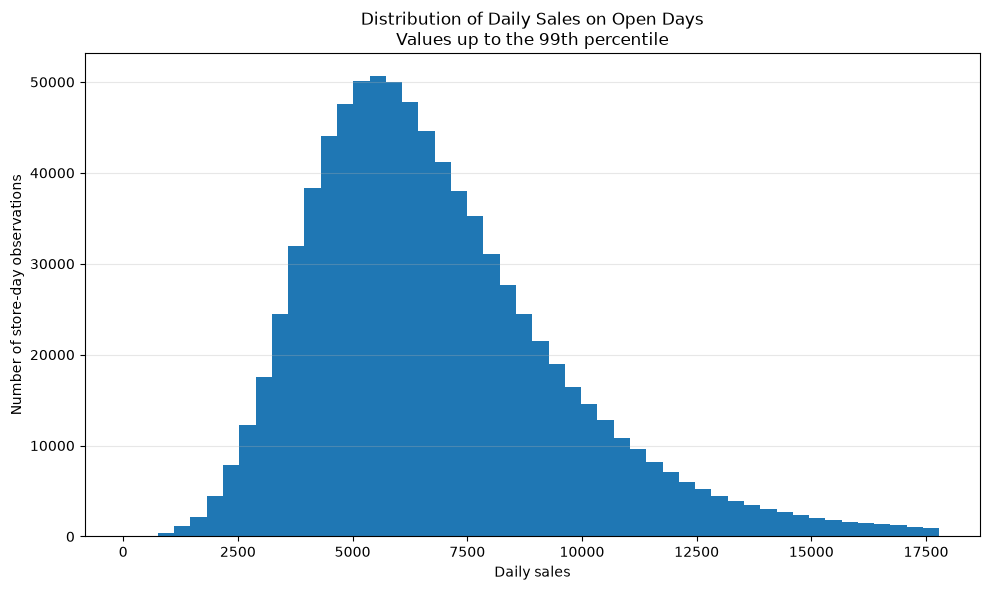

99th percentile of open positive sales: 17,789.00


In [20]:
import matplotlib.pyplot as plt

REPORT_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

sales_p99 = open_positive_sales["Sales"].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    open_positive_sales.loc[
        open_positive_sales["Sales"] <= sales_p99,
        "Sales",
    ],
    bins=50,
)

ax.set_title(
    "Distribution of Daily Sales on Open Days\n"
    "Values up to the 99th percentile"
)
ax.set_xlabel("Daily sales")
ax.set_ylabel("Number of store-day observations")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

sales_histogram_path = (
    REPORT_FIGURES_DIR
    / "eda_sales_distribution_open_days.png"
)

fig.savefig(
    sales_histogram_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"99th percentile of open positive sales: "
    f"{sales_p99:,.2f}"
)

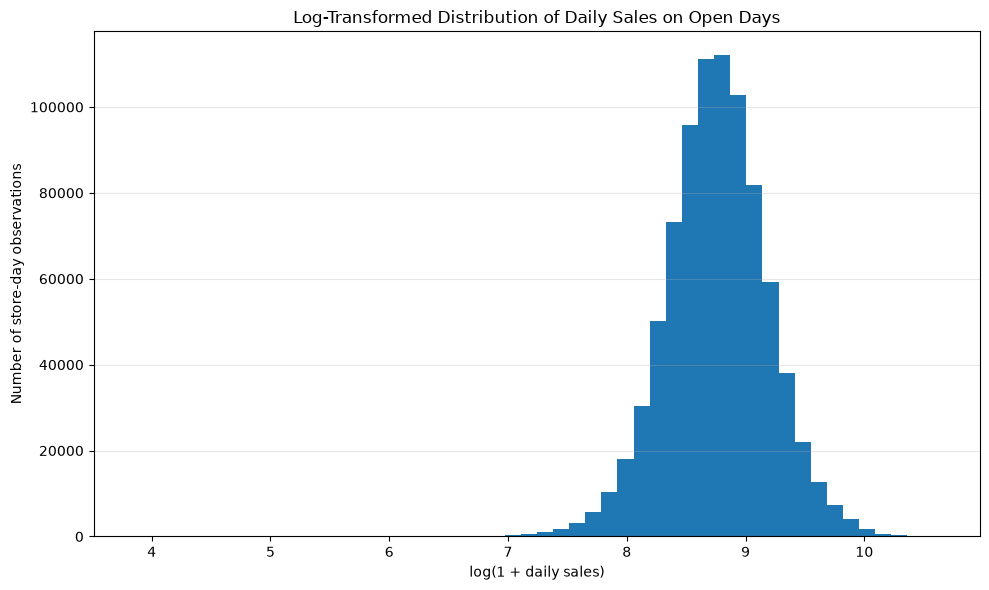

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    np.log1p(open_positive_sales["Sales"]),
    bins=50,
)

ax.set_title(
    "Log-Transformed Distribution of Daily Sales "
    "on Open Days"
)
ax.set_xlabel("log(1 + daily sales)")
ax.set_ylabel("Number of store-day observations")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

sales_log_histogram_path = (
    REPORT_FIGURES_DIR
    / "eda_sales_distribution_log_open_days.png"
)

fig.savefig(
    sales_log_histogram_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [22]:
top_sales_records = (
    train_eda.loc[
        train_eda["Sales"] > 0,
        [
            "Store",
            "Date",
            "Sales",
            "Customers",
            "Open",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
            "StoreType",
            "Assortment",
            "CompetitionDistance",
        ],
    ]
    .sort_values(
        ["Sales", "Date"],
        ascending=[False, True],
    )
    .head(25)
)

display(top_sales_records)

,Store,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance
44393,909,2015-06-22,41551,1721,1,0,0,0,a,c,"1,680.00"
132946,262,2015-04-03,38722,5132,1,1,b,0,b,a,"1,180.00"
101726,262,2015-05-01,38484,5458,1,1,a,0,b,a,"1,180.00"
87231,262,2015-05-14,38367,5192,1,0,a,1,b,a,"1,180.00"
424086,57,2014-06-16,38037,1970,1,1,0,0,d,c,420.00
627776,817,2013-12-16,38025,4381,1,1,0,0,a,a,140.00
627220,261,2013-12-16,37646,1964,1,1,0,0,d,c,"15,340.00"
444361,262,2014-05-29,37403,5297,1,0,a,0,b,a,"1,180.00"
620531,262,2013-12-22,37376,4916,1,0,0,0,b,a,"1,180.00"
245945,262,2014-12-21,37122,4962,1,0,0,0,b,a,"1,180.00"


In [23]:
sales_distribution_summary_path = (
    REPORT_TABLES_DIR
    / "eda_sales_distribution_summary.csv"
)

top_sales_records_path = (
    REPORT_TABLES_DIR
    / "eda_top_sales_records.csv"
)

sales_distribution_summary.to_csv(
    sales_distribution_summary_path,
    index=False,
)

top_sales_records.to_csv(
    top_sales_records_path,
    index=False,
)

print("Saved:")
print(
    f"- "
    f"{sales_distribution_summary_path.relative_to(PROJECT_ROOT)}"
)
print(
    f"- "
    f"{top_sales_records_path.relative_to(PROJECT_ROOT)}"
)
print(
    f"- "
    f"{sales_histogram_path.relative_to(PROJECT_ROOT)}"
)
print(
    f"- "
    f"{sales_log_histogram_path.relative_to(PROJECT_ROOT)}"
)

Saved:
- reports\tables\eda_sales_distribution_summary.csv
- reports\tables\eda_top_sales_records.csv
- reports\figures\eda_sales_distribution_open_days.png
- reports\figures\eda_sales_distribution_log_open_days.png


In [24]:
store_sales_profile = (
    open_positive_sales.groupby("Store", as_index=False)
    .agg(
        open_positive_days=("Sales", "size"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        std_sales=("Sales", "std"),
        p95_sales=(
            "Sales",
            lambda values: values.quantile(0.95),
        ),
        p99_sales=(
            "Sales",
            lambda values: values.quantile(0.99),
        ),
        maximum_sales=("Sales", "max"),
        mean_customers=("Customers", "mean"),
        median_customers=("Customers", "median"),
    )
)

display(
    store_sales_profile.describe().transpose()
)

,count,mean,std,min,25%,50%,75%,max
Store,"1,115.00",558.00,322.02,1.00,279.50,558.00,836.50,"1,115.00"
open_positive_days,"1,115.00",757.25,63.85,592.00,776.00,779.00,782.00,942.00
mean_sales,"1,115.00","6,934.63","2,383.98","2,703.74","5,322.30","6,589.95","7,964.20","21,757.48"
median_sales,"1,115.00","6,674.76","2,314.50","2,293.00","5,106.25","6,332.00","7,622.75","21,872.00"
std_sales,"1,115.00","1,845.57",623.01,575.95,"1,402.99","1,773.28","2,152.62","4,872.38"
p95_sales,"1,115.00","10,345.86","3,382.01","4,016.20","8,022.87","9,925.25","11,928.22","30,421.30"
p99_sales,"1,115.00","12,111.91","3,963.82","4,704.08","9,378.16","11,552.47","14,119.09","35,479.37"
maximum_sales,"1,115.00","15,368.40","5,357.46","5,759.00","11,700.00","14,531.00","17,944.00","41,551.00"
mean_customers,"1,115.00",754.57,353.39,240.18,541.47,678.67,866.20,"3,403.46"
median_customers,"1,115.00",746.24,350.01,230.00,535.00,669.00,852.75,"3,393.00"


In [25]:
extreme_sales_diagnostic = (
    open_positive_sales[
        [
            "Store",
            "Date",
            "Sales",
            "Customers",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
            "StoreType",
            "Assortment",
        ]
    ]
    .merge(
        store_sales_profile[
            [
                "Store",
                "median_sales",
                "p95_sales",
                "p99_sales",
                "maximum_sales",
                "median_customers",
            ]
        ],
        on="Store",
        how="left",
        validate="many_to_one",
    )
)

extreme_sales_diagnostic["sales_vs_store_median"] = (
    extreme_sales_diagnostic["Sales"]
    / extreme_sales_diagnostic["median_sales"]
)

extreme_sales_diagnostic["sales_vs_store_p99"] = (
    extreme_sales_diagnostic["Sales"]
    / extreme_sales_diagnostic["p99_sales"]
)

extreme_sales_diagnostic["sales_per_customer"] = np.where(
    extreme_sales_diagnostic["Customers"] > 0,
    extreme_sales_diagnostic["Sales"]
    / extreme_sales_diagnostic["Customers"],
    np.nan,
)

extreme_sales_diagnostic["above_store_p99"] = (
    extreme_sales_diagnostic["Sales"]
    > extreme_sales_diagnostic["p99_sales"]
).astype("int8")

print("Largest sales relative to each store's normal level:")

display(
    extreme_sales_diagnostic.sort_values(
        [
            "sales_vs_store_median",
            "Sales",
        ],
        ascending=False,
    ).head(25)
)

Largest sales relative to each store's normal level:


,Store,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,median_sales,p95_sales,p99_sales,maximum_sales,median_customers,sales_vs_store_median,sales_vs_store_p99,sales_per_customer,above_store_p99
589383,897,2013-10-02,20167,467,0,0,0,c,c,"3,267.50","5,394.55","12,767.78",20167,330.00,6.17,1.58,43.18,1
263593,708,2014-10-06,24975,1419,1,0,0,c,c,"4,288.00","7,840.20","12,030.04",24975,464.00,5.82,2.08,17.60,1
568409,126,2013-10-24,33071,574,1,0,1,d,a,"5,919.00","10,761.40","20,384.32",33071,529.00,5.59,1.62,57.61,1
634119,897,2013-08-16,17649,386,1,0,1,c,c,"3,267.50","5,394.55","12,767.78",20167,330.00,5.40,1.38,45.72,1
566950,897,2013-10-26,17298,413,0,0,0,c,c,"3,267.50","5,394.55","12,767.78",20167,330.00,5.29,1.35,41.88,1
727201,897,2013-05-08,17148,319,0,0,0,c,c,"3,267.50","5,394.55","12,767.78",20167,330.00,5.25,1.34,53.76,1
618446,897,2013-09-02,16954,261,0,0,0,c,c,"3,267.50","5,394.55","12,767.78",20167,330.00,5.19,1.33,64.96,1
734235,105,2013-04-29,22125,1354,1,0,0,a,c,"4,271.00","7,295.25","8,626.04",22125,528.00,5.18,2.56,16.34,1
570639,126,2013-10-22,30619,554,1,0,1,d,a,"5,919.00","10,761.40","20,384.32",33071,529.00,5.17,1.50,55.27,1
31594,292,2015-06-29,29161,1370,1,0,0,a,a,"5,695.50","8,633.00","9,692.15",29161,736.00,5.12,3.01,21.29,1


In [26]:
sales_per_customer_summary = (
    extreme_sales_diagnostic.loc[
        extreme_sales_diagnostic["Customers"] > 0,
        "sales_per_customer",
    ]
    .describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99,
        ]
    )
)

display(sales_per_customer_summary)

print("Highest sales per customer:")

display(
    extreme_sales_diagnostic.loc[
        extreme_sales_diagnostic["Customers"] > 0,
        [
            "Store",
            "Date",
            "Sales",
            "Customers",
            "sales_per_customer",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
            "StoreType",
            "Assortment",
        ],
    ]
    .sort_values(
        "sales_per_customer",
        ascending=False,
    )
    .head(25)
)

count   844,338.00
mean          9.49
std           2.20
min           2.75
50%           9.25
90%          12.47
95%          13.41
99%          15.19
max          64.96
Name: sales_per_customer, dtype: float64

Highest sales per customer:


,Store,Date,Sales,Customers,sales_per_customer,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment
618446,897,2013-09-02,16954,261,64.96,0,0,0,c,c
568409,126,2013-10-24,33071,574,57.61,1,0,1,d,a
570639,126,2013-10-22,30619,554,55.27,1,0,1,d,a
727201,897,2013-05-08,17148,319,53.76,0,0,0,c,c
578475,126,2013-10-14,25049,475,52.73,0,0,0,d,a
603935,897,2013-09-17,11166,216,51.69,0,0,0,c,c
573671,897,2013-10-19,16558,331,50.02,0,0,0,c,c
738383,897,2013-04-25,11805,244,48.38,1,0,0,c,c
634119,897,2013-08-16,17649,386,45.72,1,0,1,c,c
558717,897,2013-11-05,15991,353,45.30,1,0,0,c,c


In [27]:
global_high_sales = open_positive_sales.loc[
    open_positive_sales["Sales"] > sales_p99
].copy()

high_sales_by_store = (
    global_high_sales.groupby("Store", as_index=False)
    .agg(
        high_sales_days=("Date", "size"),
        mean_high_sales=("Sales", "mean"),
        maximum_sales=("Sales", "max"),
        mean_customers=("Customers", "mean"),
        promo_days=("Promo", "sum"),
    )
    .sort_values(
        [
            "high_sales_days",
            "maximum_sales",
        ],
        ascending=False,
    )
)

print(
    f"Rows above the global 99th percentile: "
    f"{len(global_high_sales):,}"
)

print(
    f"Stores represented: "
    f"{global_high_sales['Store'].nunique():,}"
)

display(high_sales_by_store.head(25))

Rows above the global 99th percentile: 8,443
Stores represented: 292


,Store,high_sales_days,mean_high_sales,maximum_sales,mean_customers,promo_days
59,262,673,"22,414.81",38722,"3,585.62",343
217,817,640,"23,355.70",38025,"3,338.18",353
291,1114,634,"21,692.61",35697,"3,319.43",337
151,562,499,"20,135.83",28680,"3,322.01",322
54,251,452,"21,319.68",35350,"2,638.00",319
133,513,392,"20,738.06",31094,"2,305.27",289
211,788,358,"20,678.03",32170,"1,915.28",299
223,842,347,"21,109.88",35154,"1,266.71",199
92,383,306,"20,021.66",28426,"2,423.63",257
202,756,249,"20,903.65",33668,"2,799.52",156


In [104]:
store_sales_profile_path = (
    REPORT_TABLES_DIR
    / "eda_store_sales_profile.csv"
)

extreme_sales_top_records_path = (
    REPORT_TABLES_DIR
    / "eda_extreme_sales_top_records.csv"
)

high_sales_by_store_path = (
    REPORT_TABLES_DIR
    / "eda_high_sales_by_store.csv"
)

# Keep only the 1,000 most extreme observations
# instead of exporting the complete row-level diagnostic.

extreme_sales_top_records = (
    extreme_sales_diagnostic
    .sort_values(
        [
            "sales_vs_store_median",
            "Sales",
        ],
        ascending=[False, False],
    )
    .head(1000)
    .copy()
)

store_sales_profile.to_csv(
    store_sales_profile_path,
    index=False,
)

extreme_sales_top_records.to_csv(
    extreme_sales_top_records_path,
    index=False,
)

high_sales_by_store.to_csv(
    high_sales_by_store_path,
    index=False,
)

print("Saved:")
print(
    f"- {store_sales_profile_path.relative_to(PROJECT_ROOT)}"
)
print(
    f"- {extreme_sales_top_records_path.relative_to(PROJECT_ROOT)}"
)
print(
    f"- {high_sales_by_store_path.relative_to(PROJECT_ROOT)}"
)

Saved:
- reports\tables\eda_store_sales_profile.csv
- reports\tables\eda_extreme_sales_top_records.csv
- reports\tables\eda_high_sales_by_store.csv


## 9. Temporal evolution of sales

In [30]:
daily_sales = (
    train_eda.groupby("Date", as_index=False)
    .agg(
        total_sales=("Sales", "sum"),
        mean_sales_all_rows=("Sales", "mean"),
        reporting_stores=("Store", "nunique"),
        open_stores=("Open", "sum"),
        promo_store_days=("Promo", "sum"),
    )
)

daily_open_sales = (
    train_eda.loc[train_eda["Open"] == 1]
    .groupby("Date", as_index=False)
    .agg(
        mean_sales_open=("Sales", "mean"),
        median_sales_open=("Sales", "median"),
        open_rows=("Store", "size"),
        positive_sales_rows=("Sales", lambda values: (values > 0).sum()),
    )
)

daily_sales = daily_sales.merge(
    daily_open_sales,
    on="Date",
    how="left",
    validate="one_to_one",
)

daily_sales["mean_sales_open_7d"] = (
    daily_sales["mean_sales_open"]
    .rolling(window=7, min_periods=1)
    .mean()
)

daily_sales["mean_sales_open_28d"] = (
    daily_sales["mean_sales_open"]
    .rolling(window=28, min_periods=1)
    .mean()
)

display(daily_sales.head())
display(daily_sales.tail())

,Date,total_sales,mean_sales_all_rows,reporting_stores,open_stores,promo_store_days,mean_sales_open,median_sales_open,open_rows,positive_sales_rows,mean_sales_open_7d,mean_sales_open_28d
0,2013-01-01,97235,87.28,1114,17,0,"5,719.71","4,220.00",17,17,"5,719.71","5,719.71"
1,2013-01-02,6949829,"6,233.03",1115,1111,0,"6,255.47","5,747.00",1111,1111,"5,987.59","5,987.59"
2,2013-01-03,6347820,"5,693.11",1115,1109,0,"5,723.91","5,308.00",1109,1109,"5,899.70","5,899.70"
3,2013-01-04,6638954,"5,954.22",1115,1108,0,"5,991.84","5,627.50",1108,1108,"5,922.73","5,922.73"
4,2013-01-05,5951593,"5,337.75",1115,1107,0,"5,376.33","5,037.00",1107,1107,"5,813.45","5,813.45"


,Date,total_sales,mean_sales_all_rows,reporting_stores,open_stores,promo_store_days,mean_sales_open,median_sales_open,open_rows,positive_sales_rows,mean_sales_open_7d,mean_sales_open_28d
937,2015-07-27,10707292,"9,602.95",1115,1113,1115,"9,620.21","9,148.00",1113,1113,"6,729.17","7,223.64"
938,2015-07-28,9115073,"8,174.95",1115,1113,1115,"8,189.64","7,764.00",1113,1113,"7,083.24","7,148.29"
939,2015-07-29,8499962,"7,623.28",1115,1113,1115,"7,636.98","7,202.00",1113,1113,"7,389.95","7,133.09"
940,2015-07-30,8798854,"7,891.35",1115,1113,1115,"7,905.53","7,525.00",1113,1113,"7,661.01","7,144.65"
941,2015-07-31,10109742,"9,067.03",1115,1113,1115,"9,083.33","8,573.00",1113,1113,"8,111.32","7,195.57"


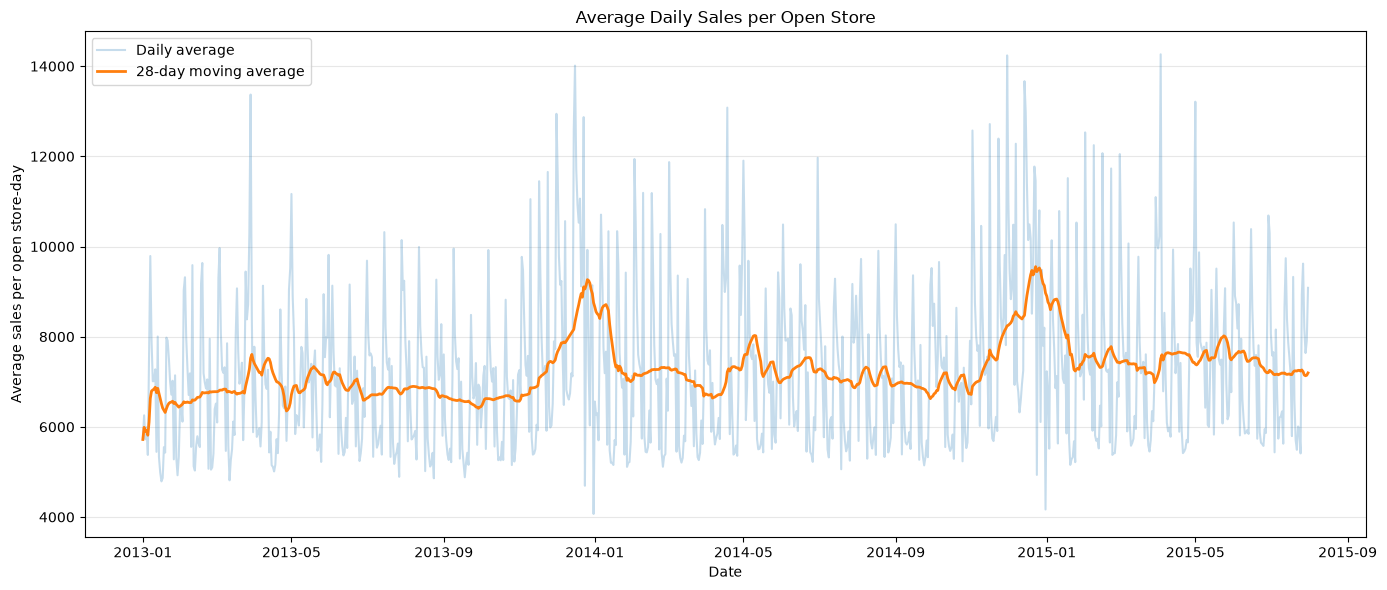

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    daily_sales["Date"],
    daily_sales["mean_sales_open"],
    alpha=0.25,
    label="Daily average",
)

ax.plot(
    daily_sales["Date"],
    daily_sales["mean_sales_open_28d"],
    linewidth=2,
    label="28-day moving average",
)

ax.set_title(
    "Average Daily Sales per Open Store"
)
ax.set_xlabel("Date")
ax.set_ylabel("Average sales per open store-day")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

daily_average_sales_path = (
    REPORT_FIGURES_DIR
    / "eda_daily_average_sales_open_stores.png"
)

fig.savefig(
    daily_average_sales_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

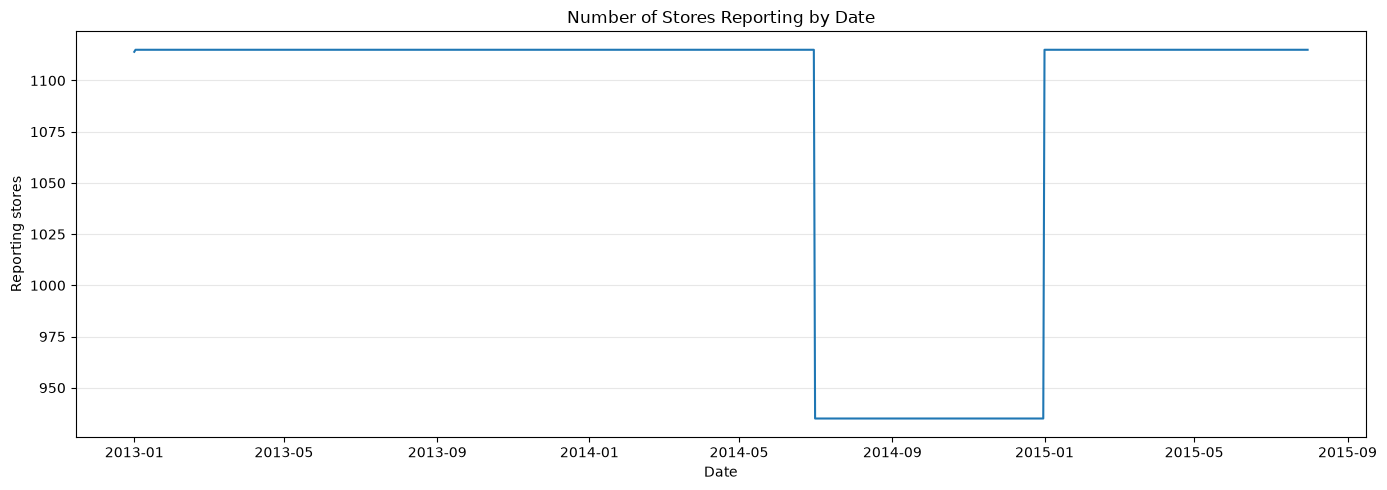

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    daily_sales["Date"],
    daily_sales["reporting_stores"],
)

ax.set_title(
    "Number of Stores Reporting by Date"
)
ax.set_xlabel("Date")
ax.set_ylabel("Reporting stores")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

reporting_stores_path = (
    REPORT_FIGURES_DIR
    / "eda_reporting_stores_by_date.png"
)

fig.savefig(
    reporting_stores_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [33]:
weekday_labels = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday",
}

weekday_sales = (
    train_eda.loc[train_eda["Open"] == 1]
    .groupby("DayOfWeek", as_index=False)
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        total_sales=("Sales", "sum"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        mean_customers=("Customers", "mean"),
        promo_share=("Promo", "mean"),
        zero_sales_rows=("Sales", lambda values: (values == 0).sum()),
    )
)

weekday_sales["DayName"] = (
    weekday_sales["DayOfWeek"].map(weekday_labels)
)

display(weekday_sales)

,DayOfWeek,rows,stores,total_sales,mean_sales,median_sales,mean_customers,promo_share,zero_sales_rows,DayName
0,1,137560,1115,1130203012,"8,216.07","7,539.00",855.44,0.56,3,Monday
1,2,143961,1115,1020411930,"7,088.11","6,502.00",769.99,0.54,6,Tuesday
2,3,141936,1115,954962863,"6,728.12","6,210.00",740.60,0.54,14,Wednesday
3,4,134644,1115,911177709,"6,767.31","6,246.00",755.57,0.55,18,Thursday
4,5,138640,1115,980555941,"7,072.68","6,580.00",781.77,0.52,7,Friday
5,6,144058,1115,846317735,"5,874.84","5,425.00",660.18,0.00,6,Saturday
6,7,3593,33,29551433,"8,224.72","6,876.00","1,441.53",0.00,0,Sunday


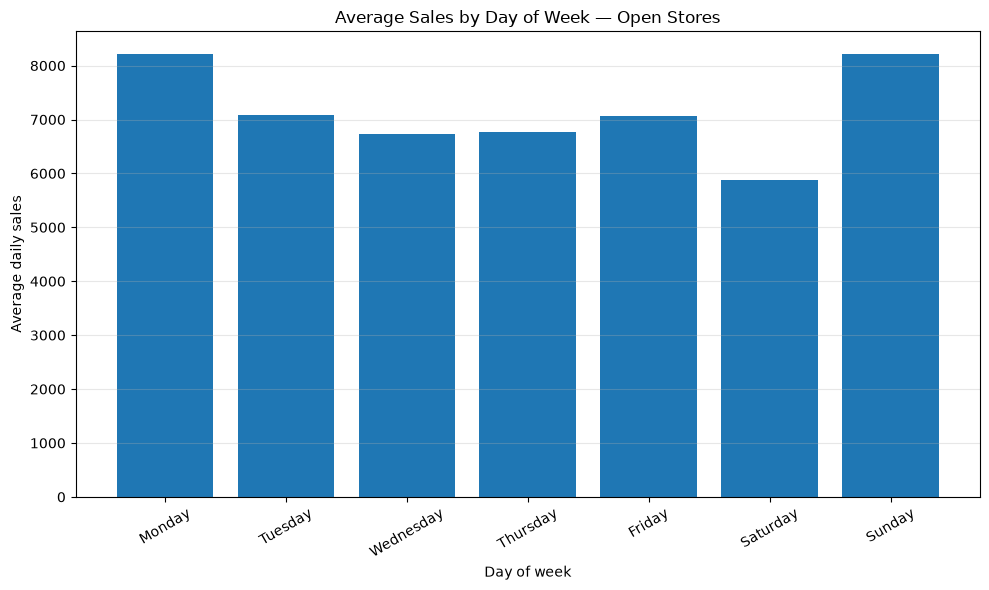

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    weekday_sales["DayName"],
    weekday_sales["mean_sales"],
)

ax.set_title(
    "Average Sales by Day of Week — Open Stores"
)
ax.set_xlabel("Day of week")
ax.set_ylabel("Average daily sales")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

weekday_sales_path = (
    REPORT_FIGURES_DIR
    / "eda_average_sales_by_weekday.png"
)

fig.savefig(
    weekday_sales_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [35]:
daily_sales_path = (
    REPORT_TABLES_DIR
    / "eda_daily_sales.csv"
)

weekday_sales_table_path = (
    REPORT_TABLES_DIR
    / "eda_weekday_sales.csv"
)

daily_sales.to_csv(
    daily_sales_path,
    index=False,
)

weekday_sales.to_csv(
    weekday_sales_table_path,
    index=False,
)

print("Saved:")
print(f"- {daily_sales_path.relative_to(PROJECT_ROOT)}")
print(f"- {weekday_sales_table_path.relative_to(PROJECT_ROOT)}")
print(f"- {daily_average_sales_path.relative_to(PROJECT_ROOT)}")
print(f"- {reporting_stores_path.relative_to(PROJECT_ROOT)}")
print(f"- {weekday_sales_path.relative_to(PROJECT_ROOT)}")

Saved:
- reports\tables\eda_daily_sales.csv
- reports\tables\eda_weekday_sales.csv
- reports\figures\eda_daily_average_sales_open_stores.png
- reports\figures\eda_reporting_stores_by_date.png
- reports\figures\eda_average_sales_by_weekday.png


## 10. Balanced-panel trend and calendar seasonality

In [37]:
full_history_days = train_eda["Date"].nunique()

complete_store_ids = store_history.loc[
    store_history["unique_dates"] == full_history_days,
    "Store",
].copy()

balanced_open_sales = train_eda.loc[
    (train_eda["Open"] == 1)
    & (train_eda["Store"].isin(complete_store_ids))
].copy()

balanced_daily_sales = (
    balanced_open_sales.groupby("Date", as_index=False)
    .agg(
        balanced_mean_sales=("Sales", "mean"),
        balanced_median_sales=("Sales", "median"),
        balanced_open_stores=("Store", "nunique"),
    )
    .sort_values("Date")
)

daily_comparison = (
    daily_sales[
        [
            "Date",
            "mean_sales_open",
            "reporting_stores",
        ]
    ]
    .merge(
        balanced_daily_sales,
        on="Date",
        how="left",
        validate="one_to_one",
    )
    .sort_values("Date")
)

daily_comparison["full_mean_28d"] = (
    daily_comparison["mean_sales_open"]
    .rolling(window=28, min_periods=1)
    .mean()
)

daily_comparison["balanced_mean_28d"] = (
    daily_comparison["balanced_mean_sales"]
    .rolling(window=28, min_periods=1)
    .mean()
)

daily_comparison["balanced_vs_full_pct"] = (
    (
        daily_comparison["balanced_mean_sales"]
        / daily_comparison["mean_sales_open"]
    )
    - 1
) * 100

print(f"Stores with complete histories: {len(complete_store_ids):,}")
print(f"Stores excluded from the balanced panel: {1115 - len(complete_store_ids):,}")

display(daily_comparison.head())

Stores with complete histories: 934
Stores excluded from the balanced panel: 181


,Date,mean_sales_open,reporting_stores,balanced_mean_sales,balanced_median_sales,balanced_open_stores,full_mean_28d,balanced_mean_28d,balanced_vs_full_pct
0,2013-01-01,"5,719.71",1114,"5,911.81","4,355.50",16,"5,719.71","5,911.81",3.36
1,2013-01-02,"6,255.47",1115,"6,327.86","5,829.00",930,"5,987.59","6,119.84",1.16
2,2013-01-03,"5,723.91",1115,"5,816.59","5,385.50",928,"5,899.70","6,018.76",1.62
3,2013-01-04,"5,991.84",1115,"6,061.91","5,736.00",928,"5,922.73","6,029.55",1.17
4,2013-01-05,"5,376.33",1115,"5,363.72","5,036.00",927,"5,813.45","5,896.38",-0.23


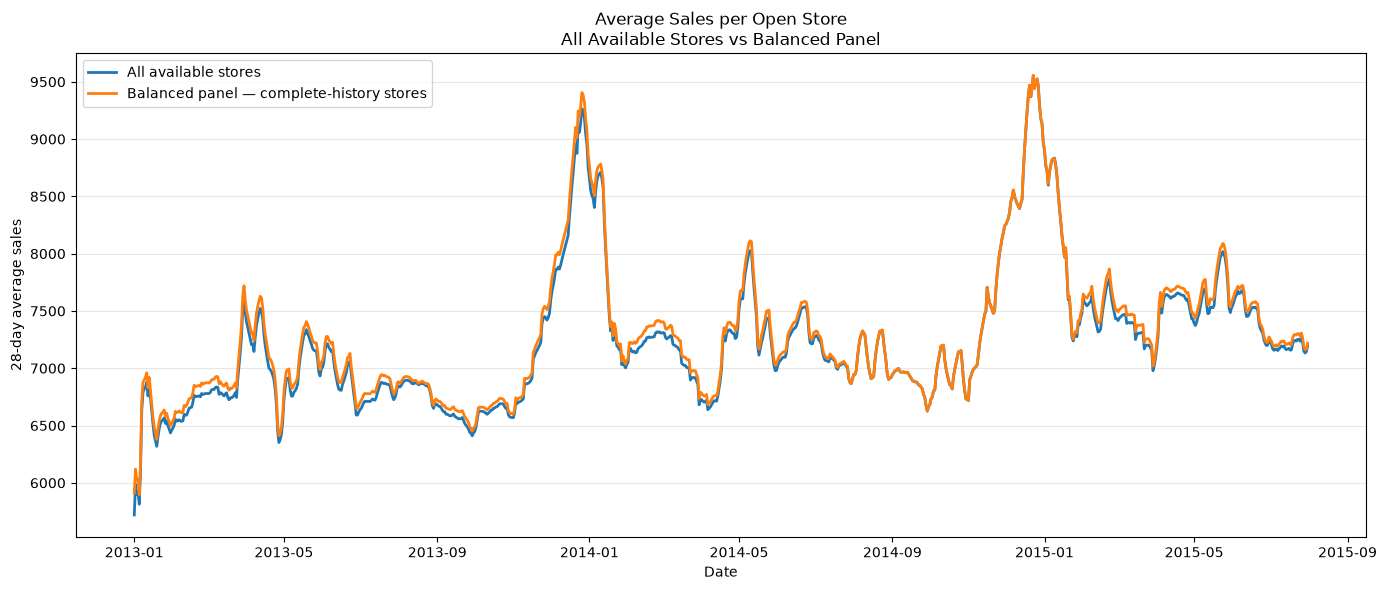

In [38]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    daily_comparison["Date"],
    daily_comparison["full_mean_28d"],
    linewidth=2,
    label="All available stores",
)

ax.plot(
    daily_comparison["Date"],
    daily_comparison["balanced_mean_28d"],
    linewidth=2,
    label="Balanced panel — complete-history stores",
)

ax.set_title(
    "Average Sales per Open Store\n"
    "All Available Stores vs Balanced Panel"
)
ax.set_xlabel("Date")
ax.set_ylabel("28-day average sales")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

balanced_trend_path = (
    REPORT_FIGURES_DIR
    / "eda_balanced_panel_sales_trend.png"
)

fig.savefig(
    balanced_trend_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [39]:
daily_comparison["Period"] = np.select(
    [
        daily_comparison["Date"] < "2014-07-01",
        daily_comparison["Date"].between(
            "2014-07-01",
            "2014-12-31",
        ),
        daily_comparison["Date"] > "2014-12-31",
    ],
    [
        "Before missing-data block",
        "Missing-data block",
        "After missing-data block",
    ],
    default="Other",
)

period_comparison = (
    daily_comparison.groupby("Period", as_index=False)
    .agg(
        days=("Date", "size"),
        full_mean_sales=("mean_sales_open", "mean"),
        balanced_mean_sales=("balanced_mean_sales", "mean"),
        mean_difference_pct=(
            "balanced_vs_full_pct",
            "mean",
        ),
        minimum_reporting_stores=(
            "reporting_stores",
            "min",
        ),
        maximum_reporting_stores=(
            "reporting_stores",
            "max",
        ),
    )
)

period_order = [
    "Before missing-data block",
    "Missing-data block",
    "After missing-data block",
]

period_comparison["Period"] = pd.Categorical(
    period_comparison["Period"],
    categories=period_order,
    ordered=True,
)

period_comparison = period_comparison.sort_values("Period")

display(period_comparison)

,Period,days,full_mean_sales,balanced_mean_sales,mean_difference_pct,minimum_reporting_stores,maximum_reporting_stores
1,Before missing-data block,546,"7,086.05","7,153.76",0.82,1114,1115
2,Missing-data block,184,"7,519.66","7,521.87",0.03,935,935
0,After missing-data block,212,"7,455.63","7,508.17",0.55,1115,1115


In [40]:
sunday_open_sales = train_eda.loc[
    (train_eda["Open"] == 1)
    & (train_eda["DayOfWeek"] == 7)
].copy()

sunday_store_ids = (
    sunday_open_sales["Store"]
    .drop_duplicates()
    .sort_values()
)

sunday_store_profile = (
    store_eda.loc[
        store_eda["Store"].isin(sunday_store_ids)
    ]
    .groupby(
        ["StoreType", "Assortment"],
        dropna=False,
        as_index=False,
    )
    .agg(
        stores=("Store", "nunique"),
    )
    .sort_values(
        "stores",
        ascending=False,
    )
)

sunday_store_profile["pct_of_sunday_stores"] = (
    sunday_store_profile["stores"]
    / sunday_store_ids.nunique()
    * 100
)

print(f"Stores that open on at least one Sunday: {sunday_store_ids.nunique():,}")

display(sunday_store_profile)

Stores that open on at least one Sunday: 33


,StoreType,Assortment,stores,pct_of_sunday_stores
0,a,c,13,39.39
2,b,b,9,27.27
1,b,a,7,21.21
5,d,c,2,6.06
3,b,c,1,3.03
4,d,a,1,3.03


In [41]:
sunday_store_weekday_profile = (
    train_eda.loc[
        (train_eda["Open"] == 1)
        & (train_eda["Store"].isin(sunday_store_ids))
    ]
    .groupby("DayOfWeek", as_index=False)
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        mean_customers=("Customers", "mean"),
        promo_share=("Promo", "mean"),
    )
)

sunday_store_weekday_profile["DayName"] = (
    sunday_store_weekday_profile["DayOfWeek"]
    .map(weekday_labels)
)

display(sunday_store_weekday_profile)

,DayOfWeek,rows,stores,mean_sales,median_sales,mean_customers,promo_share,DayName
0,1,4353,33,"9,488.19","8,520.00","1,500.16",0.54,Monday
1,2,4373,33,"8,578.18","7,606.00","1,408.57",0.53,Tuesday
2,3,4341,33,"8,381.01","7,355.00","1,396.28",0.54,Wednesday
3,4,4322,33,"8,481.13","7,418.50","1,425.59",0.54,Thursday
4,5,4312,33,"8,865.04","7,708.00","1,507.74",0.53,Friday
5,6,4359,33,"7,019.39","6,266.00","1,213.06",0.00,Saturday
6,7,3593,33,"8,224.72","6,876.00","1,441.53",0.00,Sunday


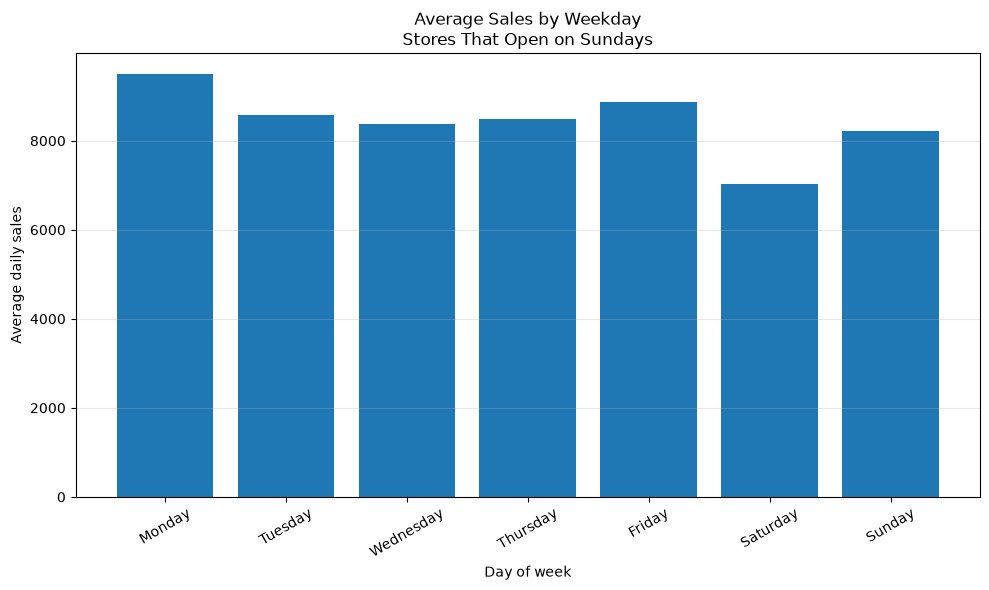

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    sunday_store_weekday_profile["DayName"],
    sunday_store_weekday_profile["mean_sales"],
)

ax.set_title(
    "Average Sales by Weekday\n"
    "Stores That Open on Sundays"
)
ax.set_xlabel("Day of week")
ax.set_ylabel("Average daily sales")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

sunday_store_weekday_path = (
    REPORT_FIGURES_DIR
    / "eda_sunday_store_weekday_profile.png"
)

fig.savefig(
    sunday_store_weekday_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [43]:
balanced_store_month = (
    balanced_open_sales.groupby(
        ["Store", "Year", "Month"],
        as_index=False,
    )
    .agg(
        mean_monthly_daily_sales=("Sales", "mean"),
        median_monthly_daily_sales=("Sales", "median"),
        open_days=("Date", "size"),
        promo_share=("Promo", "mean"),
        mean_customers=("Customers", "mean"),
    )
)

monthly_seasonality = (
    balanced_store_month.groupby("Month", as_index=False)
    .agg(
        store_month_observations=("Store", "size"),
        mean_sales=("mean_monthly_daily_sales", "mean"),
        median_sales=("mean_monthly_daily_sales", "median"),
        mean_open_days=("open_days", "mean"),
        mean_promo_share=("promo_share", "mean"),
        mean_customers=("mean_customers", "mean"),
    )
)

month_labels = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}

monthly_seasonality["MonthName"] = (
    monthly_seasonality["Month"].map(month_labels)
)

display(monthly_seasonality)

,Month,store_month_observations,mean_sales,median_sales,mean_open_days,mean_promo_share,mean_customers,MonthName
0,1,2799,"6,586.07","6,269.31",25.93,0.45,740.13,Jan
1,2,2799,"6,648.76","6,337.21",24.01,0.42,753.49,Feb
2,3,2799,"7,035.66","6,709.48",25.75,0.48,780.44,Mar
3,4,2800,"7,113.91","6,742.63",24.47,0.46,795.48,Apr
4,5,2800,"7,146.22","6,806.08",24.01,0.45,797.93,May
5,6,2799,"7,044.94","6,642.78",24.78,0.43,778.55,Jun
6,7,2801,"6,972.00","6,617.30",27.07,0.48,763.87,Jul
7,8,1867,"6,662.96","6,320.35",26.60,0.43,759.22,Aug
8,9,1867,"6,578.64","6,244.58",25.60,0.43,755.13,Sep
9,10,1868,"6,622.94","6,290.04",25.99,0.42,760.85,Oct


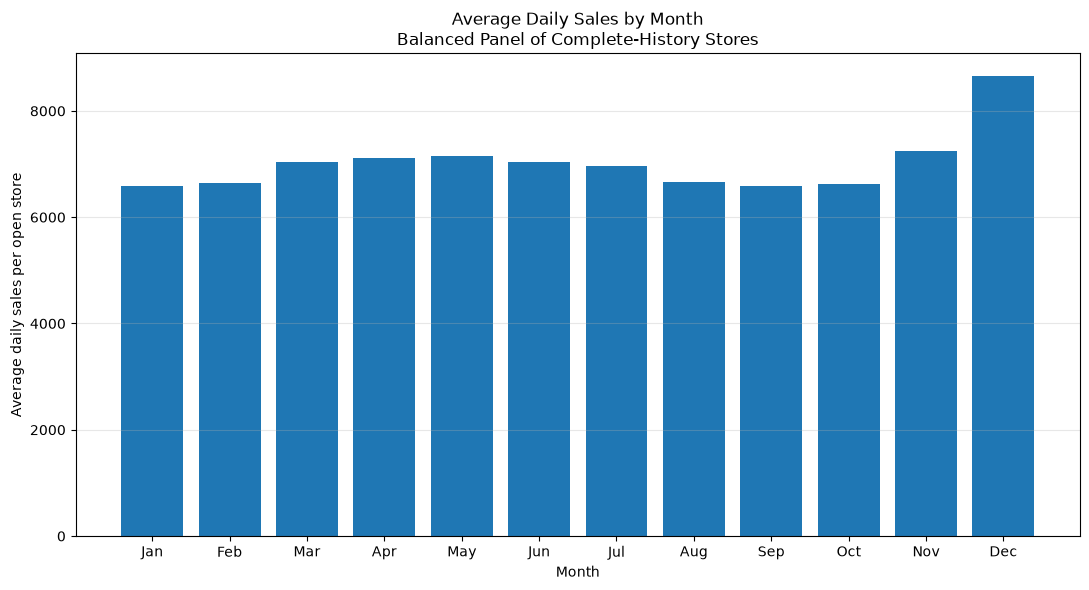

In [44]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    monthly_seasonality["MonthName"],
    monthly_seasonality["mean_sales"],
)

ax.set_title(
    "Average Daily Sales by Month\n"
    "Balanced Panel of Complete-History Stores"
)
ax.set_xlabel("Month")
ax.set_ylabel("Average daily sales per open store")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

monthly_seasonality_path = (
    REPORT_FIGURES_DIR
    / "eda_monthly_sales_seasonality.png"
)

fig.savefig(
    monthly_seasonality_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

,YearMonth,mean_sales,median_sales,total_sales,open_store_days,stores,promo_share
0,2013-01-01,"6,299.05","5,790.00",152254331,24171,931,0.38
1,2013-02-01,"6,508.53","5,971.50",145374622,22336,931,0.42
2,2013-03-01,"7,303.54","6,740.00",170617916,23361,931,0.56
3,2013-04-01,"6,649.04","6,095.00",155255181,23350,932,0.48
4,2013-05-01,"7,135.80","6,597.00",157187329,22028,932,0.48
5,2013-06-01,"6,521.35","6,006.00",152716974,23418,932,0.40
6,2013-07-01,"6,975.39","6,321.00",176575012,25314,934,0.48
7,2013-08-01,"6,631.11","6,087.00",167786888,25303,934,0.44
8,2013-09-01,"6,407.44","5,876.00",150376309,23469,934,0.40
9,2013-10-01,"6,507.85","5,983.50",157997559,24278,934,0.38


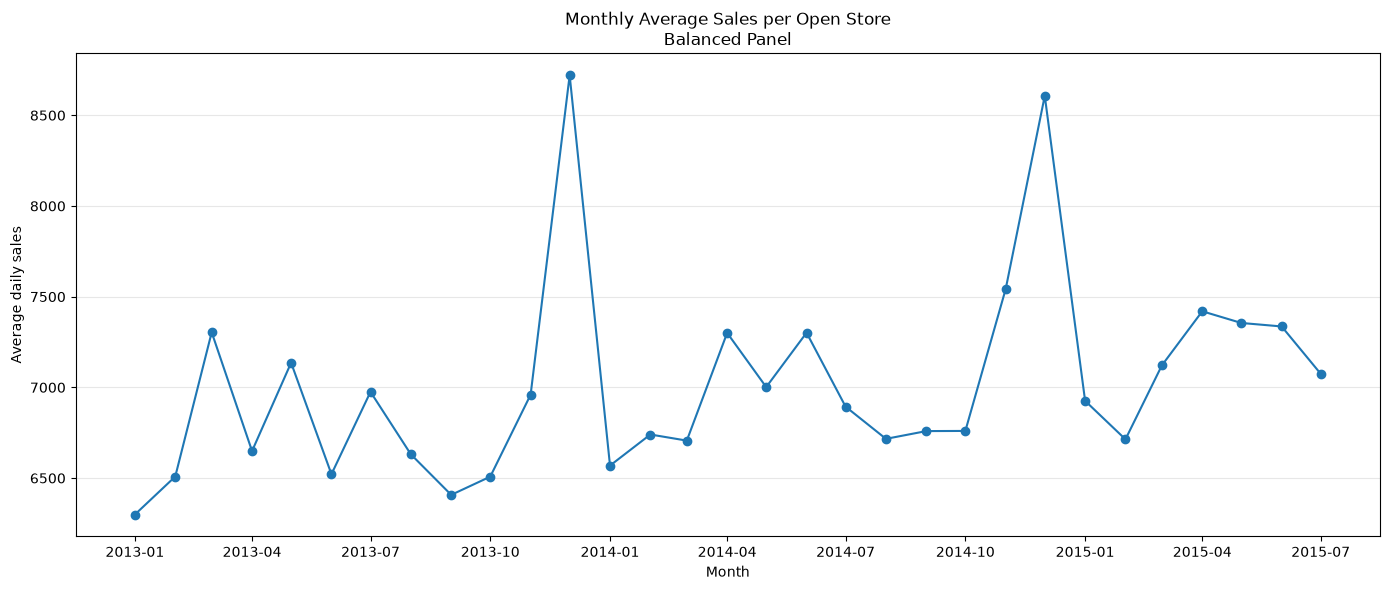

In [45]:
balanced_monthly_timeline = (
    balanced_open_sales.assign(
        YearMonth=balanced_open_sales["Date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby("YearMonth", as_index=False)
    .agg(
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        total_sales=("Sales", "sum"),
        open_store_days=("Store", "size"),
        stores=("Store", "nunique"),
        promo_share=("Promo", "mean"),
    )
)

display(balanced_monthly_timeline)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    balanced_monthly_timeline["YearMonth"],
    balanced_monthly_timeline["mean_sales"],
    marker="o",
)

ax.set_title(
    "Monthly Average Sales per Open Store\n"
    "Balanced Panel"
)
ax.set_xlabel("Month")
ax.set_ylabel("Average daily sales")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

monthly_timeline_path = (
    REPORT_FIGURES_DIR
    / "eda_monthly_sales_timeline.png"
)

fig.savefig(
    monthly_timeline_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [46]:
period_comparison_path = (
    REPORT_TABLES_DIR
    / "eda_balanced_panel_period_comparison.csv"
)

sunday_store_profile_path = (
    REPORT_TABLES_DIR
    / "eda_sunday_store_profile.csv"
)

sunday_weekday_profile_path = (
    REPORT_TABLES_DIR
    / "eda_sunday_store_weekday_profile.csv"
)

monthly_seasonality_table_path = (
    REPORT_TABLES_DIR
    / "eda_monthly_seasonality.csv"
)

monthly_timeline_table_path = (
    REPORT_TABLES_DIR
    / "eda_monthly_sales_timeline.csv"
)

period_comparison.to_csv(
    period_comparison_path,
    index=False,
)

sunday_store_profile.to_csv(
    sunday_store_profile_path,
    index=False,
)

sunday_store_weekday_profile.to_csv(
    sunday_weekday_profile_path,
    index=False,
)

monthly_seasonality.to_csv(
    monthly_seasonality_table_path,
    index=False,
)

balanced_monthly_timeline.to_csv(
    monthly_timeline_table_path,
    index=False,
)

print("Saved:")
print(f"- {period_comparison_path.relative_to(PROJECT_ROOT)}")
print(f"- {sunday_store_profile_path.relative_to(PROJECT_ROOT)}")
print(f"- {sunday_weekday_profile_path.relative_to(PROJECT_ROOT)}")
print(f"- {monthly_seasonality_table_path.relative_to(PROJECT_ROOT)}")
print(f"- {monthly_timeline_table_path.relative_to(PROJECT_ROOT)}")
print(f"- {balanced_trend_path.relative_to(PROJECT_ROOT)}")
print(f"- {sunday_store_weekday_path.relative_to(PROJECT_ROOT)}")
print(f"- {monthly_seasonality_path.relative_to(PROJECT_ROOT)}")
print(f"- {monthly_timeline_path.relative_to(PROJECT_ROOT)}")

Saved:
- reports\tables\eda_balanced_panel_period_comparison.csv
- reports\tables\eda_sunday_store_profile.csv
- reports\tables\eda_sunday_store_weekday_profile.csv
- reports\tables\eda_monthly_seasonality.csv
- reports\tables\eda_monthly_sales_timeline.csv
- reports\figures\eda_balanced_panel_sales_trend.png
- reports\figures\eda_sunday_store_weekday_profile.png
- reports\figures\eda_monthly_sales_seasonality.png
- reports\figures\eda_monthly_sales_timeline.png


## 11. Promotions, holidays, and store-format drivers

In [48]:
promo_summary = (
    train_eda.loc[train_eda["Open"] == 1]
    .groupby("Promo", as_index=False)
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        total_sales=("Sales", "sum"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        mean_customers=("Customers", "mean"),
        median_customers=("Customers", "median"),
        zero_sales_rows=("Sales", lambda values: (values == 0).sum()),
    )
)

non_promo_mean = promo_summary.loc[
    promo_summary["Promo"] == 0,
    "mean_sales",
].iloc[0]

promo_summary["sales_vs_non_promo_pct"] = (
    promo_summary["mean_sales"] / non_promo_mean - 1
) * 100

display(promo_summary)

,Promo,rows,stores,total_sales,mean_sales,median_sales,mean_customers,median_customers,zero_sales_rows,sales_vs_non_promo_pct
0,0,467496,1115,2771974337,"5,929.41","5,459.00",696.86,610.00,33,0.00
1,1,376896,1115,3101206286,"8,228.28","7,649.00",844.43,757.00,21,38.77


In [50]:
promo_weekday = (
    train_eda.loc[train_eda["Open"] == 1]
    .groupby(["DayOfWeek", "Promo"], as_index=False)
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        mean_customers=("Customers", "mean"),
    )
)

promo_weekday["DayName"] = (
    promo_weekday["DayOfWeek"].map(weekday_labels)
)

promo_weekday_pivot = (
    promo_weekday.pivot(
        index=["DayOfWeek", "DayName"],
        columns="Promo",
        values="mean_sales",
    )
    .reset_index()
    .rename(
        columns={
            0: "mean_sales_no_promo",
            1: "mean_sales_promo",
        }
    )
)

promo_weekday_pivot["promo_uplift_pct"] = (
    promo_weekday_pivot["mean_sales_promo"]
    / promo_weekday_pivot["mean_sales_no_promo"]
    - 1
) * 100

display(promo_weekday)
display(promo_weekday_pivot)

,DayOfWeek,Promo,rows,stores,mean_sales,median_sales,mean_customers,DayName
0,1,0,60317,1115,"6,222.52","5,625.00",742.78,Monday
1,1,1,77243,1115,"9,772.78","9,225.00",943.42,Monday
2,2,0,66843,1115,"5,716.24","5,251.00",687.53,Tuesday
3,2,1,77118,1115,"8,277.20","7,750.00",841.46,Tuesday
4,3,0,65679,1115,"5,617.04","5,217.00",672.55,Wednesday
5,3,1,76257,1115,"7,685.08","7,176.00",799.20,Wednesday
6,4,0,60521,1115,"5,749.84","5,353.00",688.75,Thursday
7,4,1,74123,1115,"7,598.07","7,085.00",810.13,Thursday
8,5,0,66485,1115,"6,344.03","5,901.00",735.19,Friday
9,5,1,72155,1115,"7,744.07","7,258.00",824.69,Friday


Promo,DayOfWeek,DayName,mean_sales_no_promo,mean_sales_promo,promo_uplift_pct
0,1,Monday,"6,222.52","9,772.78",57.06
1,2,Tuesday,"5,716.24","8,277.20",44.80
2,3,Wednesday,"5,617.04","7,685.08",36.82
3,4,Thursday,"5,749.84","7,598.07",32.14
4,5,Friday,"6,344.03","7,744.07",22.07
5,6,Saturday,"5,874.84",NaN,NaN
6,7,Sunday,"8,224.72",NaN,NaN


In [51]:
store_promo_sales = (
    train_eda.loc[train_eda["Open"] == 1]
    .groupby(["Store", "Promo"], as_index=False)
    .agg(
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        rows=("Sales", "size"),
        mean_customers=("Customers", "mean"),
    )
)

store_promo_pivot = (
    store_promo_sales.pivot(
        index="Store",
        columns="Promo",
        values="mean_sales",
    )
    .reset_index()
    .rename(
        columns={
            0: "mean_sales_no_promo",
            1: "mean_sales_promo",
        }
    )
)

store_promo_pivot = store_promo_pivot.dropna(
    subset=[
        "mean_sales_no_promo",
        "mean_sales_promo",
    ]
)

store_promo_pivot["promo_uplift_pct"] = (
    store_promo_pivot["mean_sales_promo"]
    / store_promo_pivot["mean_sales_no_promo"]
    - 1
) * 100

store_promo_pivot = store_promo_pivot.merge(
    store_eda[
        [
            "Store",
            "StoreType",
            "Assortment",
        ]
    ],
    on="Store",
    how="left",
    validate="one_to_one",
)

print("Store-level descriptive promotion uplift:")
display(
    store_promo_pivot["promo_uplift_pct"]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
)

display(
    store_promo_pivot.sort_values(
        "promo_uplift_pct",
        ascending=False,
    ).head(20)
)

Store-level descriptive promotion uplift:


count   1,115.00
mean       41.43
std        18.10
min        -6.95
10%        19.97
25%        29.36
50%        40.56
75%        51.84
90%        64.05
max       144.93
Name: promo_uplift_pct, dtype: float64

,Store,mean_sales_no_promo,mean_sales_promo,promo_uplift_pct,StoreType,Assortment
197,198,"1,753.46","4,294.73",144.93,a,a
606,607,"2,551.57","5,542.97",117.24,a,a
542,543,"1,868.13","3,926.07",110.16,c,a
574,575,"3,614.41","7,586.11",109.89,a,a
692,693,"4,577.87","9,107.82",98.95,d,a
270,271,"5,452.70","10,746.49",97.09,a,a
551,552,"5,412.45","10,565.75",95.21,a,a
95,96,"3,638.35","7,047.62",93.70,a,a
634,635,"4,159.05","8,048.37",93.51,a,a
488,489,"5,143.06","9,950.41",93.47,a,a


In [52]:
promo_by_store_format = (
    store_promo_pivot.groupby(
        ["StoreType", "Assortment"],
        as_index=False,
    )
    .agg(
        stores=("Store", "nunique"),
        mean_promo_uplift_pct=("promo_uplift_pct", "mean"),
        median_promo_uplift_pct=("promo_uplift_pct", "median"),
    )
    .sort_values(
        "mean_promo_uplift_pct",
        ascending=False,
    )
)

display(promo_by_store_format)

,StoreType,Assortment,stores,mean_promo_uplift_pct,median_promo_uplift_pct
0,a,a,381,49.00,47.10
7,d,a,128,42.50,43.48
1,a,c,221,40.33,41.30
5,c,a,77,37.37,35.93
2,b,a,7,35.44,35.98
8,d,c,220,34.55,34.70
6,c,c,71,33.40,32.43
4,b,c,1,20.53,20.53
3,b,b,9,6.22,7.66


In [53]:
train_eda["StateHolidayCode"] = (
    train_eda["StateHoliday"].astype(str)
)

state_holiday_opening = (
    train_eda.groupby("StateHolidayCode", as_index=False)
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        open_rate=("Open", "mean"),
        total_sales=("Sales", "sum"),
        mean_sales_all_rows=("Sales", "mean"),
    )
)

state_holiday_open_sales = (
    train_eda.loc[train_eda["Open"] == 1]
    .groupby("StateHolidayCode", as_index=False)
    .agg(
        open_rows=("Sales", "size"),
        open_stores=("Store", "nunique"),
        mean_sales_open=("Sales", "mean"),
        median_sales_open=("Sales", "median"),
        mean_customers_open=("Customers", "mean"),
        promo_share_open=("Promo", "mean"),
    )
)

state_holiday_summary = state_holiday_opening.merge(
    state_holiday_open_sales,
    on="StateHolidayCode",
    how="left",
    validate="one_to_one",
)

display(state_holiday_summary)

,StateHolidayCode,rows,stores,open_rate,total_sales,mean_sales_all_rows,open_rows,open_stores,mean_sales_open,median_sales_open,mean_customers_open,promo_share_open
0,0,986159,1115,0.86,5865164768,"5,947.48",843482,1115,"6,953.52","6,368.00",762.08,0.45
1,a,20260,1115,0.03,5890305,290.74,694,156,"8,487.47","7,556.00","1,279.17",0.56
2,b,6690,1115,0.02,1433744,214.31,145,32,"9,887.89","8,423.00","1,686.89",0.34
3,c,4100,1115,0.02,691806,168.73,71,20,"9,743.75","8,397.00","1,569.23",0.00


In [54]:
school_holiday_summary = (
    train_eda.loc[train_eda["Open"] == 1]
    .groupby("SchoolHoliday", as_index=False)
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        mean_customers=("Customers", "mean"),
        promo_share=("Promo", "mean"),
    )
)

school_no_holiday_mean = school_holiday_summary.loc[
    school_holiday_summary["SchoolHoliday"] == 0,
    "mean_sales",
].iloc[0]

school_holiday_summary["sales_vs_no_holiday_pct"] = (
    school_holiday_summary["mean_sales"]
    / school_no_holiday_mean
    - 1
) * 100

display(school_holiday_summary)

,SchoolHoliday,rows,stores,mean_sales,median_sales,mean_customers,promo_share,sales_vs_no_holiday_pct
0,0,680935,1115,"6,896.78","6,326.00",757.83,0.44,0.00
1,1,163457,1115,"7,200.18","6,562.00",783.12,0.48,4.40


In [55]:
store_format_base = (
    train_eda.loc[train_eda["Open"] == 1]
    .groupby(
        [
            "Store",
            "StoreType",
            "Assortment",
        ],
        as_index=False,
    )
    .agg(
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        mean_customers=("Customers", "mean"),
        promo_share=("Promo", "mean"),
        open_days=("Date", "size"),
    )
)

store_format_summary = (
    store_format_base.groupby(
        ["StoreType", "Assortment"],
        as_index=False,
    )
    .agg(
        stores=("Store", "nunique"),
        mean_of_store_mean_sales=("mean_sales", "mean"),
        median_of_store_mean_sales=("mean_sales", "median"),
        mean_customers=("mean_customers", "mean"),
        mean_promo_share=("promo_share", "mean"),
        mean_open_days=("open_days", "mean"),
    )
    .sort_values(
        "mean_of_store_mean_sales",
        ascending=False,
    )
)

store_format_summary["Format"] = (
    "Type "
    + store_format_summary["StoreType"]
    + " / Assortment "
    + store_format_summary["Assortment"]
)

display(store_format_summary)

,StoreType,Assortment,stores,mean_of_store_mean_sales,median_of_store_mean_sales,mean_customers,mean_promo_share,mean_open_days,Format
4,b,c,1,"17,969.56","17,969.56","3,105.05",0.38,942.00,Type b / Assortment c
2,b,a,7,"10,987.85","10,828.40","1,780.64",0.38,915.57,Type b / Assortment a
3,b,b,9,"8,555.42","7,687.46","2,045.33",0.38,912.44,Type b / Assortment b
1,a,c,221,"7,577.77","7,157.55",854.83,0.45,773.86,Type a / Assortment c
8,d,c,220,"7,056.14","6,853.91",617.49,0.45,749.49,Type d / Assortment c
6,c,c,71,"7,010.14","6,271.13",784.56,0.45,766.44,Type c / Assortment c
5,c,a,77,"6,831.50","6,728.37",837.31,0.45,760.53,Type c / Assortment a
0,a,a,381,"6,526.68","6,046.87",755.76,0.45,750.80,Type a / Assortment a
7,d,a,128,"6,424.31","6,314.12",581.37,0.45,733.48,Type d / Assortment a


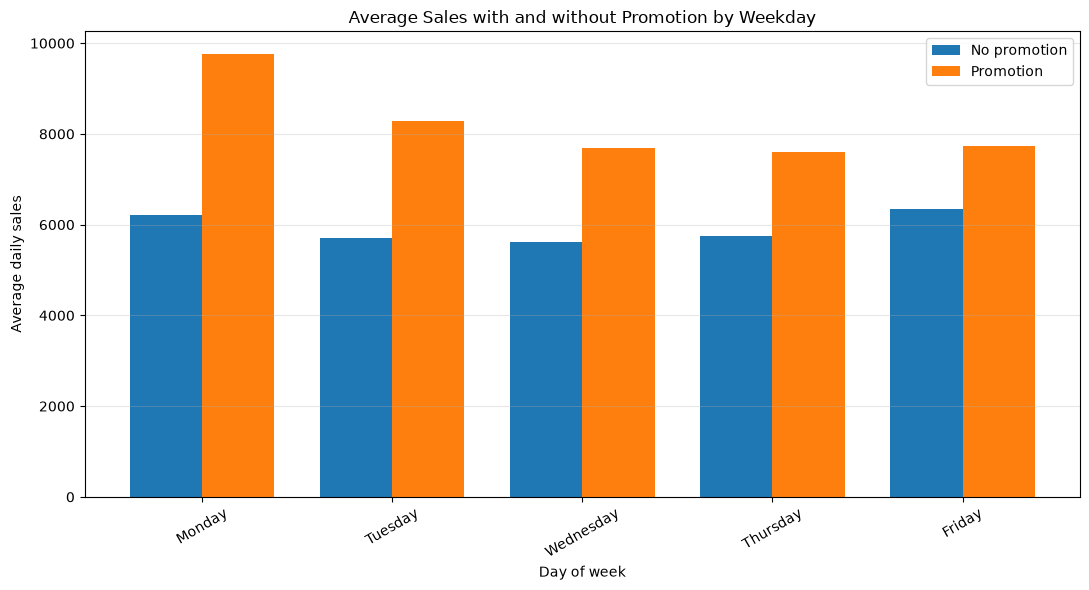

In [56]:
promo_weekday_plot = promo_weekday_pivot.dropna(
    subset=[
        "mean_sales_no_promo",
        "mean_sales_promo",
    ]
)

x_positions = np.arange(len(promo_weekday_plot))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    x_positions - bar_width / 2,
    promo_weekday_plot["mean_sales_no_promo"],
    width=bar_width,
    label="No promotion",
)

ax.bar(
    x_positions + bar_width / 2,
    promo_weekday_plot["mean_sales_promo"],
    width=bar_width,
    label="Promotion",
)

ax.set_xticks(x_positions)
ax.set_xticklabels(
    promo_weekday_plot["DayName"],
    rotation=30,
)

ax.set_title(
    "Average Sales with and without Promotion by Weekday"
)
ax.set_xlabel("Day of week")
ax.set_ylabel("Average daily sales")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

promo_weekday_path = (
    REPORT_FIGURES_DIR
    / "eda_promotion_sales_by_weekday.png"
)

fig.savefig(
    promo_weekday_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

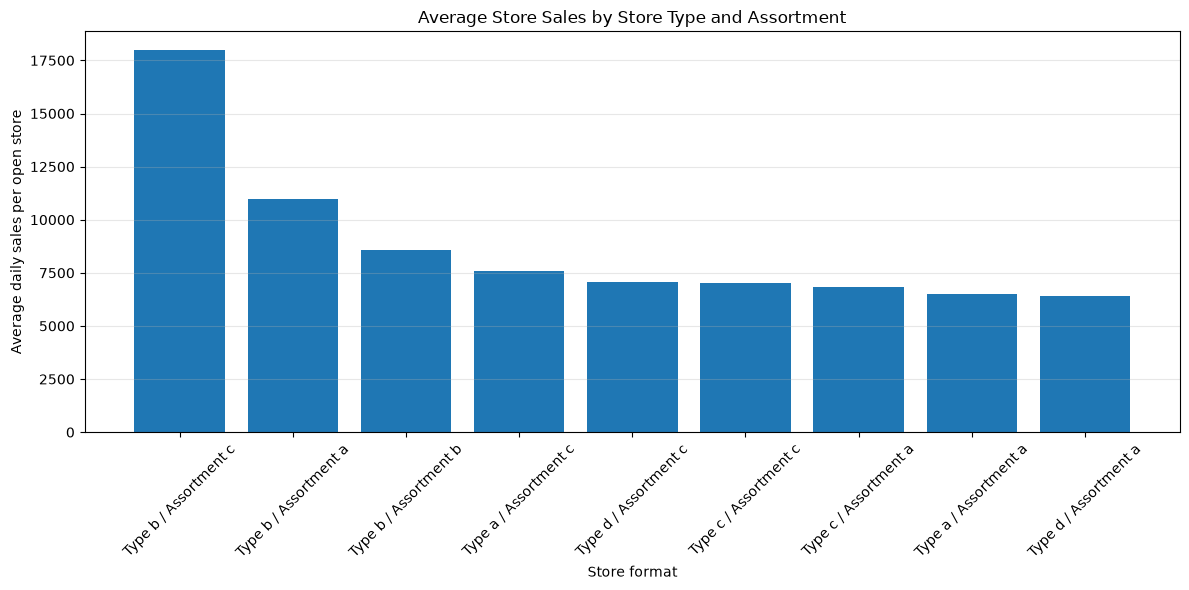

In [57]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    store_format_summary["Format"],
    store_format_summary["mean_of_store_mean_sales"],
)

ax.set_title(
    "Average Store Sales by Store Type and Assortment"
)
ax.set_xlabel("Store format")
ax.set_ylabel("Average daily sales per open store")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

store_format_path = (
    REPORT_FIGURES_DIR
    / "eda_sales_by_store_format.png"
)

fig.savefig(
    store_format_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [58]:
promo_summary_path = (
    REPORT_TABLES_DIR / "eda_promo_summary.csv"
)

promo_weekday_table_path = (
    REPORT_TABLES_DIR / "eda_promo_by_weekday.csv"
)

store_promo_uplift_path = (
    REPORT_TABLES_DIR / "eda_store_promo_uplift.csv"
)

promo_format_path = (
    REPORT_TABLES_DIR / "eda_promo_by_store_format.csv"
)

state_holiday_path = (
    REPORT_TABLES_DIR / "eda_state_holiday_summary.csv"
)

school_holiday_path = (
    REPORT_TABLES_DIR / "eda_school_holiday_summary.csv"
)

store_format_table_path = (
    REPORT_TABLES_DIR / "eda_store_format_summary.csv"
)

promo_summary.to_csv(promo_summary_path, index=False)
promo_weekday_pivot.to_csv(
    promo_weekday_table_path,
    index=False,
)
store_promo_pivot.to_csv(
    store_promo_uplift_path,
    index=False,
)
promo_by_store_format.to_csv(
    promo_format_path,
    index=False,
)
state_holiday_summary.to_csv(
    state_holiday_path,
    index=False,
)
school_holiday_summary.to_csv(
    school_holiday_path,
    index=False,
)
store_format_summary.to_csv(
    store_format_table_path,
    index=False,
)

print("Saved:")
print(f"- {promo_summary_path.relative_to(PROJECT_ROOT)}")
print(f"- {promo_weekday_table_path.relative_to(PROJECT_ROOT)}")
print(f"- {store_promo_uplift_path.relative_to(PROJECT_ROOT)}")
print(f"- {promo_format_path.relative_to(PROJECT_ROOT)}")
print(f"- {state_holiday_path.relative_to(PROJECT_ROOT)}")
print(f"- {school_holiday_path.relative_to(PROJECT_ROOT)}")
print(f"- {store_format_table_path.relative_to(PROJECT_ROOT)}")
print(f"- {promo_weekday_path.relative_to(PROJECT_ROOT)}")
print(f"- {store_format_path.relative_to(PROJECT_ROOT)}")

Saved:
- reports\tables\eda_promo_summary.csv
- reports\tables\eda_promo_by_weekday.csv
- reports\tables\eda_store_promo_uplift.csv
- reports\tables\eda_promo_by_store_format.csv
- reports\tables\eda_state_holiday_summary.csv
- reports\tables\eda_school_holiday_summary.csv
- reports\tables\eda_store_format_summary.csv
- reports\figures\eda_promotion_sales_by_weekday.png
- reports\figures\eda_sales_by_store_format.png


## 12. Competition and Promo2 analysis

In [60]:
store_competition_profile = (
    train_eda.loc[train_eda["Open"] == 1]
    .groupby("Store", as_index=False)
    .agg(
        mean_sales_open=("Sales", "mean"),
        median_sales_open=("Sales", "median"),
        mean_customers=("Customers", "mean"),
        open_days=("Date", "size"),
    )
    .merge(
        store_eda[
            [
                "Store",
                "StoreType",
                "Assortment",
                "CompetitionDistance",
                "CompetitionOpenSinceMonth",
                "CompetitionOpenSinceYear",
            ]
        ],
        on="Store",
        how="left",
        validate="one_to_one",
    )
)

store_competition_profile["CompetitionDistanceMissing"] = (
    store_competition_profile["CompetitionDistance"]
    .isna()
    .astype("int8")
)

print("Competition distance summary:")

display(
    store_competition_profile["CompetitionDistance"]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

print("Stores without competition distance:")

display(
    store_competition_profile.loc[
        store_competition_profile[
            "CompetitionDistance"
        ].isna()
    ]
)

Competition distance summary:


count    1,112.00
mean     5,404.90
std      7,663.17
min         20.00
10%        250.00
25%        717.50
50%      2,325.00
75%      6,882.50
90%     15,679.00
95%     20,144.50
99%     35,144.70
max     75,860.00
Name: CompetitionDistance, dtype: float64

Stores without competition distance:


,Store,mean_sales_open,median_sales_open,mean_customers,open_days,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,CompetitionDistanceMissing
290,291,"8,023.04","7,777.50",840.35,780,d,a,NaN,NaN,NaN,1
621,622,"4,317.96","4,253.50",430.00,784,a,c,NaN,NaN,NaN,1
878,879,"3,762.98","3,585.50",347.33,622,d,a,NaN,NaN,NaN,1


In [61]:
valid_competition_distance = (
    store_competition_profile.loc[
        store_competition_profile[
            "CompetitionDistance"
        ].notna()
    ]
    .copy()
)

valid_competition_distance[
    "CompetitionDistanceGroup"
] = pd.qcut(
    valid_competition_distance["CompetitionDistance"],
    q=5,
    duplicates="drop",
)

competition_distance_profile = (
    valid_competition_distance.groupby(
        "CompetitionDistanceGroup",
        observed=True,
        as_index=False,
    )
    .agg(
        stores=("Store", "nunique"),
        minimum_distance=(
            "CompetitionDistance",
            "min",
        ),
        median_distance=(
            "CompetitionDistance",
            "median",
        ),
        maximum_distance=(
            "CompetitionDistance",
            "max",
        ),
        mean_store_sales=(
            "mean_sales_open",
            "mean",
        ),
        median_store_sales=(
            "mean_sales_open",
            "median",
        ),
        mean_customers=(
            "mean_customers",
            "mean",
        ),
    )
)

competition_distance_spearman = (
    valid_competition_distance[
        [
            "CompetitionDistance",
            "mean_sales_open",
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(
    "Spearman correlation between competition distance "
    f"and store-level mean sales: "
    f"{competition_distance_spearman:.3f}"
)

display(competition_distance_profile)

Spearman correlation between competition distance and store-level mean sales: -0.028


,CompetitionDistanceGroup,stores,minimum_distance,median_distance,maximum_distance,mean_store_sales,median_store_sales,mean_customers
0,"(19.999, 520.0]",226,20.00,250.00,520.00,"7,552.97","6,996.33",954.05
1,"(520.0, 1600.0]",221,530.00,"1,060.00","1,600.00","6,783.74","6,063.51",795.78
2,"(1600.0, 3450.0]",221,"1,610.00","2,330.00","3,450.00","6,719.41","6,464.32",706.09
3,"(3450.0, 8666.0]",221,"3,460.00","5,300.00","8,650.00","6,798.29","6,629.75",662.93
4,"(8666.0, 75860.0]",223,"8,670.00","15,700.00","75,860.00","6,824.88","6,703.40",653.03


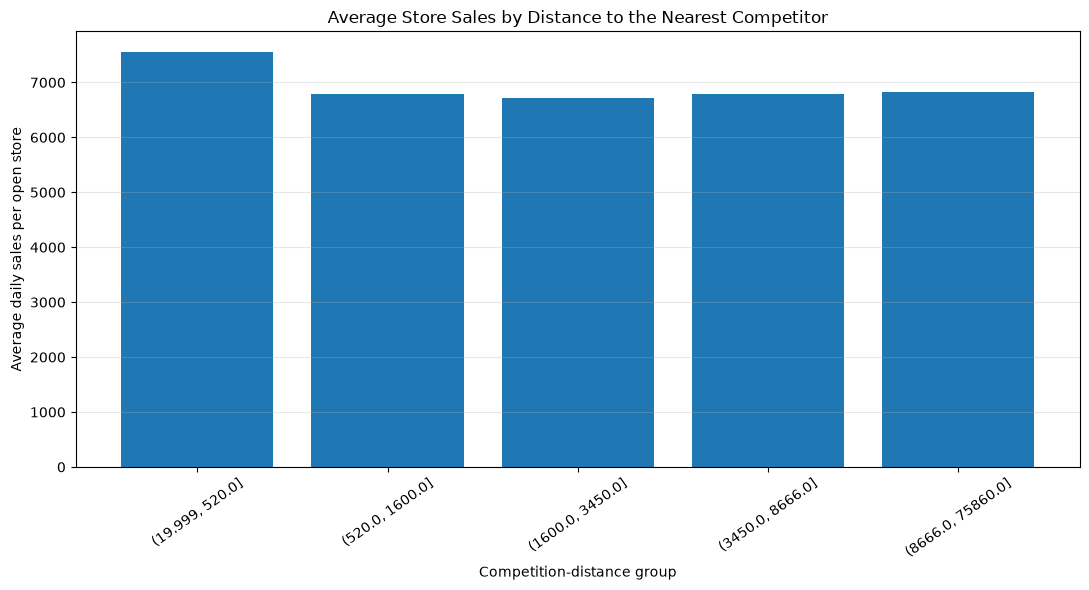

In [62]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    competition_distance_profile[
        "CompetitionDistanceGroup"
    ].astype(str),
    competition_distance_profile[
        "mean_store_sales"
    ],
)

ax.set_title(
    "Average Store Sales by Distance "
    "to the Nearest Competitor"
)
ax.set_xlabel("Competition-distance group")
ax.set_ylabel("Average daily sales per open store")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

competition_distance_path = (
    REPORT_FIGURES_DIR
    / "eda_sales_by_competition_distance.png"
)

fig.savefig(
    competition_distance_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [66]:
competition_year_text = (
    train_eda["CompetitionOpenSinceYear"]
    .astype("Int64")
    .astype("string")
)

competition_month_text = (
    train_eda["CompetitionOpenSinceMonth"]
    .astype("Int64")
    .astype("string")
    .str.zfill(2)
)

competition_start_text = (
    competition_year_text
    + "-"
    + competition_month_text
    + "-01"
)

train_eda["CompetitionStartDate"] = pd.to_datetime(
    competition_start_text,
    errors="coerce",
)

competition_start_known = (
    train_eda["CompetitionStartDate"].notna()
)

competition_active = (
    competition_start_known
    & (
        train_eda["Date"]
        >= train_eda["CompetitionStartDate"]
    )
)

competition_month_difference = (
    (
        train_eda["Date"].dt.year
        - train_eda["CompetitionStartDate"].dt.year
    )
    * 12
    + (
        train_eda["Date"].dt.month
        - train_eda["CompetitionStartDate"].dt.month
    )
)

train_eda["CompetitionActive"] = (
    competition_active.astype("int8")
)

train_eda["CompetitionStartMissing"] = (
    ~competition_start_known
).astype("int8")

train_eda["CompetitionMonthsOpen"] = np.where(
    competition_active,
    competition_month_difference,
    np.where(
        competition_start_known,
        0,
        np.nan,
    ),
)

train_eda["CompetitionStatus"] = np.select(
    [
        ~competition_start_known,
        competition_start_known & ~competition_active,
        competition_active,
    ],
    [
        "Unknown opening date",
        "Competitor not yet active",
        "Competitor active",
    ],
    default="Unknown",
)

In [67]:
print(
    [
        "CompetitionStartDate",
        "CompetitionActive",
        "CompetitionStartMissing",
        "CompetitionMonthsOpen",
        "CompetitionStatus",
    ]
)

print("\nCompetition opening-date coverage:")

competition_date_validation = pd.DataFrame(
    {
        "metric": [
            "Rows with known competition start date",
            "Rows with missing competition start date",
            "Rows with active competitor",
            "Rows before competitor opening",
        ],
        "rows": [
            train_eda["CompetitionStartDate"].notna().sum(),
            train_eda["CompetitionStartDate"].isna().sum(),
            (train_eda["CompetitionActive"] == 1).sum(),
            (
                (train_eda["CompetitionStartDate"].notna())
                & (train_eda["CompetitionActive"] == 0)
            ).sum(),
        ],
    }
)

display(competition_date_validation)

print("\nCompetition status distribution:")

display(
    train_eda["CompetitionStatus"]
    .value_counts(dropna=False)
    .rename_axis("CompetitionStatus")
    .reset_index(name="rows")
)

print("\nSample rows:")

display(
    train_eda[
        [
            "Store",
            "Date",
            "CompetitionOpenSinceMonth",
            "CompetitionOpenSinceYear",
            "CompetitionStartDate",
            "CompetitionActive",
            "CompetitionMonthsOpen",
            "CompetitionStatus",
        ]
    ].head(20)
)

['CompetitionStartDate', 'CompetitionActive', 'CompetitionStartMissing', 'CompetitionMonthsOpen', 'CompetitionStatus']

Competition opening-date coverage:


,metric,rows
0,Rows with known competition start date,693861
1,Rows with missing competition start date,323348
2,Rows with active competitor,609195
3,Rows before competitor opening,84666



Competition status distribution:


,CompetitionStatus,rows
0,Competitor active,609195
1,Unknown opening date,323348
2,Competitor not yet active,84666



Sample rows:


,Store,Date,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,CompetitionStartDate,CompetitionActive,CompetitionMonthsOpen,CompetitionStatus
0,1,2015-07-31,9.00,"2,008.00",2008-09-01,1,82.00,Competitor active
1,2,2015-07-31,11.00,"2,007.00",2007-11-01,1,92.00,Competitor active
2,3,2015-07-31,12.00,"2,006.00",2006-12-01,1,103.00,Competitor active
3,4,2015-07-31,9.00,"2,009.00",2009-09-01,1,70.00,Competitor active
4,5,2015-07-31,4.00,"2,015.00",2015-04-01,1,3.00,Competitor active
5,6,2015-07-31,12.00,"2,013.00",2013-12-01,1,19.00,Competitor active
6,7,2015-07-31,4.00,"2,013.00",2013-04-01,1,27.00,Competitor active
7,8,2015-07-31,10.00,"2,014.00",2014-10-01,1,9.00,Competitor active
8,9,2015-07-31,8.00,"2,000.00",2000-08-01,1,179.00,Competitor active
9,10,2015-07-31,9.00,"2,009.00",2009-09-01,1,70.00,Competitor active


In [68]:
competition_status_summary = (
    train_eda.loc[train_eda["Open"] == 1]
    .groupby(
        "CompetitionStatus",
        as_index=False,
    )
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        mean_customers=("Customers", "mean"),
        promo_share=("Promo", "mean"),
    )
)

display(competition_status_summary)

,CompetitionStatus,rows,stores,mean_sales,median_sales,mean_customers,promo_share
0,Competitor active,505665,758,"6,932.04","6,343.00",760.63,0.45
1,Competitor not yet active,70108,191,"7,215.28","6,620.00",781.52,0.44
2,Unknown opening date,268619,354,"6,931.90","6,350.00",761.78,0.45


In [69]:
active_competition_rows = (
    train_eda.loc[
        (train_eda["Open"] == 1)
        & (train_eda["CompetitionActive"] == 1)
    ]
    .copy()
)

active_competition_rows[
    "CompetitionAgeBand"
] = pd.cut(
    active_competition_rows[
        "CompetitionMonthsOpen"
    ],
    bins=[
        -1,
        6,
        12,
        24,
        60,
        120,
        np.inf,
    ],
    labels=[
        "0–6 months",
        "7–12 months",
        "13–24 months",
        "25–60 months",
        "61–120 months",
        "More than 120 months",
    ],
)

competition_age_profile = (
    active_competition_rows.groupby(
        "CompetitionAgeBand",
        observed=True,
        as_index=False,
    )
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        mean_customers=("Customers", "mean"),
        promo_share=("Promo", "mean"),
    )
)

display(competition_age_profile)

,CompetitionAgeBand,rows,stores,mean_sales,median_sales,mean_customers,promo_share
0,0–6 months,34419,250,"7,098.65","6,416.00",776.90,0.44
1,7–12 months,31195,234,"7,140.90","6,488.00",776.15,0.44
2,13–24 months,56190,250,"7,134.85","6,457.00",779.65,0.45
3,25–60 months,131095,332,"6,896.51","6,454.00",755.41,0.45
4,61–120 months,179289,334,"6,832.42","6,172.00",750.37,0.45
5,More than 120 months,73477,139,"6,916.71","6,330.00",766.22,0.45


In [70]:
store_promo2 = store_eda.copy()

promo2_year_text = (
    store_promo2["Promo2SinceYear"]
    .astype("Int64")
    .astype("string")
)

promo2_week_text = (
    store_promo2["Promo2SinceWeek"]
    .astype("Int64")
    .astype("string")
    .str.zfill(2)
)

promo2_start_text = (
    promo2_year_text
    + "-W"
    + promo2_week_text
    + "-1"
)

store_promo2["Promo2StartDate"] = pd.to_datetime(
    promo2_start_text,
    format="%G-W%V-%u",
    errors="coerce",
)

promo2_start_map = (
    store_promo2.set_index("Store")[
        "Promo2StartDate"
    ]
)

train_eda["Promo2StartDate"] = (
    train_eda["Store"].map(promo2_start_map)
)

print("Promo2 start-date validation:")

display(
    store_promo2.groupby("Promo2", as_index=False)
    .agg(
        stores=("Store", "nunique"),
        known_start_dates=(
            "Promo2StartDate",
            "count",
        ),
    )
)

Promo2 start-date validation:


,Promo2,stores,known_start_dates
0,0,544,0
1,1,571,571


In [72]:
promo_interval_months = {
    "Jan,Apr,Jul,Oct": {1, 4, 7, 10},
    "Feb,May,Aug,Nov": {2, 5, 8, 11},
    "Mar,Jun,Sept,Dec": {3, 6, 9, 12},
}

train_eda["Promo2ScheduledMonth"] = np.fromiter(
    (
        int(
            int(month)
            in promo_interval_months.get(
                interval,
                set(),
            )
        )
        for month, interval in zip(
            train_eda["Month"].to_numpy(),
            train_eda[
                "PromoInterval"
            ].fillna("").to_numpy(),
        )
    ),
    dtype=np.int8,
    count=len(train_eda),
)

train_eda["Promo2Active"] = (
    (train_eda["Promo2"] == 1)
    & train_eda["Promo2StartDate"].notna()
    & (
        train_eda["Date"]
        >= train_eda["Promo2StartDate"]
    )
    & (
        train_eda["Promo2ScheduledMonth"]
        == 1
    )
).astype("int8")

In [74]:
print("New Promo2 variables created:")

print(
    [
        "Promo2ScheduledMonth",
        "Promo2Active",
    ]
)

promo2_validation = pd.DataFrame(
    {
        "metric": [
            "Stores participating in Promo2",
            "Stores with at least one active Promo2 day",
            "Rows belonging to Promo2 stores",
            "Rows in a scheduled Promo2 month",
            "Rows with Promo2 active",
            "Active rows incorrectly assigned to non-participants",
        ],
        "value": [
            train_eda.loc[
                train_eda["Promo2"] == 1,
                "Store",
            ].nunique(),
            train_eda.loc[
                train_eda["Promo2Active"] == 1,
                "Store",
            ].nunique(),
            int((train_eda["Promo2"] == 1).sum()),
            int(train_eda["Promo2ScheduledMonth"].sum()),
            int(train_eda["Promo2Active"].sum()),
            int(
                (
                    (train_eda["Promo2"] == 0)
                    & (train_eda["Promo2Active"] == 1)
                ).sum()
            ),
        ],
    }
)

display(promo2_validation)

New Promo2 variables created:
['Promo2ScheduledMonth', 'Promo2Active']


,metric,value
0,Stores participating in Promo2,571
1,Stores with at least one active Promo2 day,571
2,Rows belonging to Promo2 stores,509178
3,Rows in a scheduled Promo2 month,174792
4,Rows with Promo2 active,152052
5,Active rows incorrectly assigned to non-partic...,0


In [75]:
promo2_sample = (
    train_eda.loc[
        train_eda["Promo2"] == 1,
        [
            "Store",
            "Date",
            "Month",
            "Promo2",
            "Promo2StartDate",
            "PromoInterval",
            "Promo2ScheduledMonth",
            "Promo2Active",
        ],
    ]
    .sort_values(["Store", "Date"])
)

display(promo2_sample.head(25))

,Store,Date,Month,Promo2,Promo2StartDate,PromoInterval,Promo2ScheduledMonth,Promo2Active
1016096,2,2013-01-01,1,1,2010-03-29,"Jan,Apr,Jul,Oct",1,1
1014981,2,2013-01-02,1,1,2010-03-29,"Jan,Apr,Jul,Oct",1,1
1013866,2,2013-01-03,1,1,2010-03-29,"Jan,Apr,Jul,Oct",1,1
1012751,2,2013-01-04,1,1,2010-03-29,"Jan,Apr,Jul,Oct",1,1
1011636,2,2013-01-05,1,1,2010-03-29,"Jan,Apr,Jul,Oct",1,1
1010521,2,2013-01-06,1,1,2010-03-29,"Jan,Apr,Jul,Oct",1,1
1009406,2,2013-01-07,1,1,2010-03-29,"Jan,Apr,Jul,Oct",1,1
1008291,2,2013-01-08,1,1,2010-03-29,"Jan,Apr,Jul,Oct",1,1
1007176,2,2013-01-09,1,1,2010-03-29,"Jan,Apr,Jul,Oct",1,1
1006061,2,2013-01-10,1,1,2010-03-29,"Jan,Apr,Jul,Oct",1,1


In [76]:
promo2_interval_validation = (
    train_eda.loc[
        train_eda["Promo2"] == 1
    ]
    .groupby(
        [
            "PromoInterval",
            "Month",
            "Promo2ScheduledMonth",
        ],
        as_index=False,
    )
    .agg(
        rows=("Date", "size"),
        stores=("Store", "nunique"),
        active_rows=("Promo2Active", "sum"),
    )
    .sort_values(
        [
            "PromoInterval",
            "Month",
        ]
    )
)

display(promo2_interval_validation)

,PromoInterval,Month,Promo2ScheduledMonth,rows,stores,active_rows
0,"Feb,May,Aug,Nov",1,0,12090,130,0
1,"Feb,May,Aug,Nov",2,1,10920,130,9744
2,"Feb,May,Aug,Nov",3,0,12090,130,0
3,"Feb,May,Aug,Nov",4,0,11700,130,0
4,"Feb,May,Aug,Nov",5,1,12090,130,11067
5,"Feb,May,Aug,Nov",6,0,11700,130,0
6,"Feb,May,Aug,Nov",7,0,11439,130,0
7,"Feb,May,Aug,Nov",8,1,7409,130,6975
8,"Feb,May,Aug,Nov",9,0,7170,130,0
9,"Feb,May,Aug,Nov",10,0,7409,130,0


In [77]:
promo2_participant_rows = (
    train_eda.loc[
        (train_eda["Open"] == 1)
        & (train_eda["Promo2"] == 1)
    ]
    .copy()
)

promo2_activity_summary = (
    promo2_participant_rows.groupby(
        "Promo2Active",
        as_index=False,
    )
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        mean_customers=("Customers", "mean"),
        promo_share=("Promo", "mean"),
    )
)

display(promo2_activity_summary)

,Promo2Active,rows,stores,mean_sales,median_sales,mean_customers,promo_share
0,0,294705,571,"6,596.18","6,096.00",685.44,0.44
1,1,126380,571,"6,470.26","6,028.00",671.90,0.45


In [78]:
store_promo2_sales = (
    promo2_participant_rows.groupby(
        ["Store", "Promo2Active"],
        as_index=False,
    )
    .agg(
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        rows=("Sales", "size"),
    )
)

store_promo2_uplift = (
    store_promo2_sales.pivot(
        index="Store",
        columns="Promo2Active",
        values="mean_sales",
    )
    .reset_index()
    .rename(
        columns={
            0: "mean_sales_promo2_inactive",
            1: "mean_sales_promo2_active",
        }
    )
    .dropna(
        subset=[
            "mean_sales_promo2_inactive",
            "mean_sales_promo2_active",
        ]
    )
)

store_promo2_uplift[
    "promo2_uplift_pct"
] = (
    store_promo2_uplift[
        "mean_sales_promo2_active"
    ]
    / store_promo2_uplift[
        "mean_sales_promo2_inactive"
    ]
    - 1
) * 100

store_promo2_uplift = (
    store_promo2_uplift.merge(
        store_eda[
            [
                "Store",
                "StoreType",
                "Assortment",
                "PromoInterval",
            ]
        ],
        on="Store",
        how="left",
        validate="one_to_one",
    )
)

print("Store-level Promo2 descriptive uplift:")

display(
    store_promo2_uplift[
        "promo2_uplift_pct"
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
)

Store-level Promo2 descriptive uplift:


count   571.00
mean     -0.57
std       5.84
min     -25.76
10%      -5.49
25%      -4.00
50%      -2.19
75%       2.28
90%       5.99
max      53.06
Name: promo2_uplift_pct, dtype: float64

In [79]:
promo_promo2_interaction = (
    promo2_participant_rows.groupby(
        ["Promo", "Promo2Active"],
        as_index=False,
    )
    .agg(
        rows=("Sales", "size"),
        stores=("Store", "nunique"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        mean_customers=("Customers", "mean"),
    )
)

display(promo_promo2_interaction)

,Promo,Promo2Active,rows,stores,mean_sales,median_sales,mean_customers
0,0,0,163991,571,"5,575.24","5,214.00",622.31
1,0,1,69210,571,"5,419.36","5,108.00",608.45
2,1,0,130714,571,"7,877.03","7,377.00",764.64
3,1,1,57170,571,"7,742.48","7,317.00",748.71


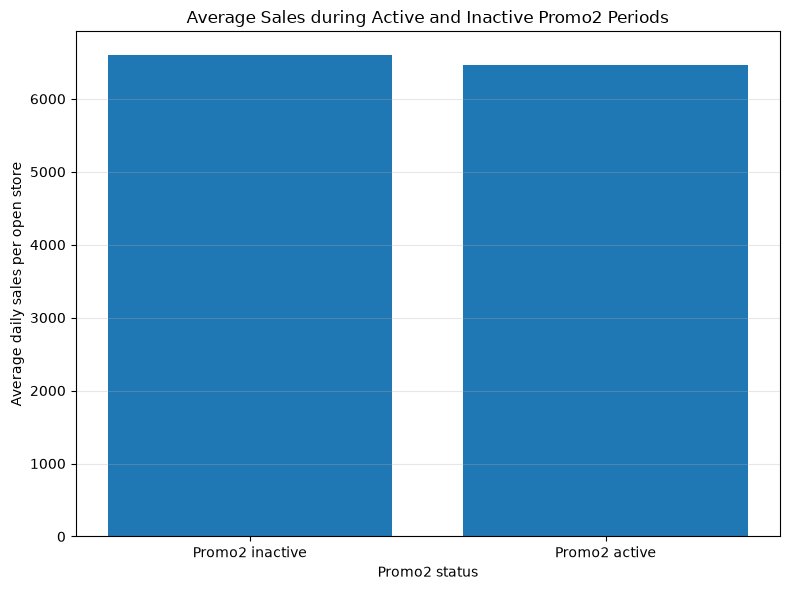

In [80]:
promo2_plot_labels = {
    0: "Promo2 inactive",
    1: "Promo2 active",
}

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    promo2_activity_summary[
        "Promo2Active"
    ].map(promo2_plot_labels),
    promo2_activity_summary["mean_sales"],
)

ax.set_title(
    "Average Sales during Active and Inactive "
    "Promo2 Periods"
)
ax.set_xlabel("Promo2 status")
ax.set_ylabel("Average daily sales per open store")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

promo2_activity_path = (
    REPORT_FIGURES_DIR
    / "eda_promo2_activity_sales.png"
)

fig.savefig(
    promo2_activity_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [81]:
store_competition_profile_path = (
    REPORT_TABLES_DIR
    / "eda_store_competition_profile.csv"
)

competition_distance_table_path = (
    REPORT_TABLES_DIR
    / "eda_competition_distance_profile.csv"
)

competition_status_path = (
    REPORT_TABLES_DIR
    / "eda_competition_status_summary.csv"
)

competition_age_path = (
    REPORT_TABLES_DIR
    / "eda_competition_age_profile.csv"
)

promo2_activity_table_path = (
    REPORT_TABLES_DIR
    / "eda_promo2_activity_summary.csv"
)

store_promo2_uplift_path = (
    REPORT_TABLES_DIR
    / "eda_store_promo2_uplift.csv"
)

promo_promo2_interaction_path = (
    REPORT_TABLES_DIR
    / "eda_promo_promo2_interaction.csv"
)

store_competition_profile.to_csv(
    store_competition_profile_path,
    index=False,
)

competition_distance_profile.to_csv(
    competition_distance_table_path,
    index=False,
)

competition_status_summary.to_csv(
    competition_status_path,
    index=False,
)

competition_age_profile.to_csv(
    competition_age_path,
    index=False,
)

promo2_activity_summary.to_csv(
    promo2_activity_table_path,
    index=False,
)

store_promo2_uplift.to_csv(
    store_promo2_uplift_path,
    index=False,
)

promo_promo2_interaction.to_csv(
    promo_promo2_interaction_path,
    index=False,
)

print("Saved:")
print(f"- {store_competition_profile_path.relative_to(PROJECT_ROOT)}")
print(f"- {competition_distance_table_path.relative_to(PROJECT_ROOT)}")
print(f"- {competition_status_path.relative_to(PROJECT_ROOT)}")
print(f"- {competition_age_path.relative_to(PROJECT_ROOT)}")
print(f"- {promo2_activity_table_path.relative_to(PROJECT_ROOT)}")
print(f"- {store_promo2_uplift_path.relative_to(PROJECT_ROOT)}")
print(f"- {promo_promo2_interaction_path.relative_to(PROJECT_ROOT)}")
print(f"- {competition_distance_path.relative_to(PROJECT_ROOT)}")
print(f"- {promo2_activity_path.relative_to(PROJECT_ROOT)}")

Saved:
- reports\tables\eda_store_competition_profile.csv
- reports\tables\eda_competition_distance_profile.csv
- reports\tables\eda_competition_status_summary.csv
- reports\tables\eda_competition_age_profile.csv
- reports\tables\eda_promo2_activity_summary.csv
- reports\tables\eda_store_promo2_uplift.csv
- reports\tables\eda_promo_promo2_interaction.csv
- reports\figures\eda_sales_by_competition_distance.png
- reports\figures\eda_promo2_activity_sales.png


## 13. Train-test comparability and missing Open values

In [83]:
test_path = RAW_DATA_DIR / "test.csv"

test_eda = pd.read_csv(
    test_path,
    low_memory=False,
)

test_eda["Date"] = pd.to_datetime(
    test_eda["Date"],
    errors="raise",
)

test_eda = test_eda.merge(
    store_eda,
    on="Store",
    how="left",
    validate="many_to_one",
)

test_eda["Year"] = test_eda["Date"].dt.year
test_eda["Month"] = test_eda["Date"].dt.month
test_eda["Day"] = test_eda["Date"].dt.day
test_eda["ISOWeek"] = (
    test_eda["Date"]
    .dt.isocalendar()
    .week
    .astype("int16")
)

print(f"Test rows: {len(test_eda):,}")
print(f"Test stores: {test_eda['Store'].nunique():,}")
print(
    f"Test period: {test_eda['Date'].min()} "
    f"to {test_eda['Date'].max()}"
)
print(
    f"Missing Open values: "
    f"{test_eda['Open'].isna().sum():,}"
)

Test rows: 41,088
Test stores: 856
Test period: 2015-08-01 00:00:00 to 2015-09-17 00:00:00
Missing Open values: 11


In [84]:
missing_open_test = (
    test_eda.loc[
        test_eda["Open"].isna()
    ]
    .copy()
    .sort_values(
        ["Date", "Store"]
    )
)

display(
    missing_open_test[
        [
            "Id",
            "Store",
            "Date",
            "DayOfWeek",
            "Open",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
            "StoreType",
            "Assortment",
            "Promo2",
        ]
    ]
)

,Id,Store,Date,DayOfWeek,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,Promo2
10751,10752,622,2015-09-05,6,NaN,0,0,0,a,c,0
9039,9040,622,2015-09-07,1,NaN,0,0,0,a,c,0
8183,8184,622,2015-09-08,2,NaN,0,0,0,a,c,0
7327,7328,622,2015-09-09,3,NaN,0,0,0,a,c,0
6471,6472,622,2015-09-10,4,NaN,0,0,0,a,c,0
5615,5616,622,2015-09-11,5,NaN,0,0,0,a,c,0
4759,4760,622,2015-09-12,6,NaN,0,0,0,a,c,0
3047,3048,622,2015-09-14,1,NaN,1,0,0,a,c,0
2191,2192,622,2015-09-15,2,NaN,1,0,0,a,c,0
1335,1336,622,2015-09-16,3,NaN,1,0,0,a,c,0


In [86]:
historical_open_pattern = (
    train_eda.groupby(
        ["Store", "DayOfWeek"],
        as_index=False,
    )
    .agg(
        historical_rows=("Open", "size"),
        historical_open_days=("Open", "sum"),
        historical_open_rate=("Open", "mean"),
    )
)

recent_same_weekday = (
    train_eda.sort_values(
        [
            "Store",
            "DayOfWeek",
            "Date",
        ]
    )
    .groupby(
        ["Store", "DayOfWeek"],
        group_keys=False,
    )
    .tail(8)
    .groupby(
        ["Store", "DayOfWeek"],
        as_index=False,
    )
    .agg(
        recent_rows=("Open", "size"),
        recent_open_days=("Open", "sum"),
        recent_open_rate=("Open", "mean"),
        last_historical_date=("Date", "max"),
    )
)

missing_open_diagnostic = (
    missing_open_test.merge(
        historical_open_pattern,
        on=[
            "Store",
            "DayOfWeek",
        ],
        how="left",
        validate="many_to_one",
    )
    .merge(
        recent_same_weekday,
        on=[
            "Store",
            "DayOfWeek",
        ],
        how="left",
        validate="many_to_one",
    )
)

In [87]:
print("Historical opening pattern created:")
print(f"- Rows: {len(historical_open_pattern):,}")
print(
    f"- Stores represented: "
    f"{historical_open_pattern['Store'].nunique():,}"
)

display(historical_open_pattern.head(20))

print("\nRecent same-weekday pattern created:")
print(f"- Rows: {len(recent_same_weekday):,}")
print(
    f"- Stores represented: "
    f"{recent_same_weekday['Store'].nunique():,}"
)

display(recent_same_weekday.head(20))

Historical opening pattern created:
- Rows: 7,805
- Stores represented: 1,115


,Store,DayOfWeek,historical_rows,historical_open_days,historical_open_rate
0,1,1,134,128,0.96
1,1,2,135,134,0.99
2,1,3,135,132,0.98
3,1,4,135,124,0.92
4,1,5,135,129,0.96
5,1,6,134,134,1.00
6,1,7,134,0,0.00
7,2,1,134,128,0.96
8,2,2,135,134,0.99
9,2,3,135,132,0.98



Recent same-weekday pattern created:
- Rows: 7,805
- Stores represented: 1,115


,Store,DayOfWeek,recent_rows,recent_open_days,recent_open_rate,last_historical_date
0,1,1,8,8,1.00,2015-07-27
1,1,2,8,8,1.00,2015-07-28
2,1,3,8,8,1.00,2015-07-29
3,1,4,8,8,1.00,2015-07-30
4,1,5,8,8,1.00,2015-07-31
5,1,6,8,8,1.00,2015-07-25
6,1,7,8,0,0.00,2015-07-26
7,2,1,8,8,1.00,2015-07-27
8,2,2,8,8,1.00,2015-07-28
9,2,3,8,8,1.00,2015-07-29


In [88]:
missing_open_store_ids = (
    missing_open_test["Store"]
    .drop_duplicates()
    .tolist()
)

print("Historical opening patterns for affected stores:")

display(
    historical_open_pattern.loc[
        historical_open_pattern["Store"].isin(
            missing_open_store_ids
        )
    ]
    .sort_values(
        ["Store", "DayOfWeek"]
    )
)

print("Recent same-weekday patterns for affected stores:")

display(
    recent_same_weekday.loc[
        recent_same_weekday["Store"].isin(
            missing_open_store_ids
        )
    ]
    .sort_values(
        ["Store", "DayOfWeek"]
    )
)

Historical opening patterns for affected stores:


,Store,DayOfWeek,historical_rows,historical_open_days,historical_open_rate
4347,622,1,134,128,0.96
4348,622,2,135,134,0.99
4349,622,3,135,132,0.98
4350,622,4,135,127,0.94
4351,622,5,135,129,0.96
4352,622,6,134,134,1.00
4353,622,7,134,0,0.00


Recent same-weekday patterns for affected stores:


,Store,DayOfWeek,recent_rows,recent_open_days,recent_open_rate,last_historical_date
4347,622,1,8,8,1.00,2015-07-27
4348,622,2,8,8,1.00,2015-07-28
4349,622,3,8,8,1.00,2015-07-29
4350,622,4,8,8,1.00,2015-07-30
4351,622,5,8,8,1.00,2015-07-31
4352,622,6,8,8,1.00,2015-07-25
4353,622,7,8,0,0.00,2015-07-26


In [89]:
test_open_lookup = (
    test_eda.set_index(
        ["Store", "Date"]
    )["Open"]
    .to_dict()
)

missing_open_diagnostic["OpenPreviousWeek"] = [
    test_open_lookup.get(
        (
            store_id,
            date - pd.Timedelta(days=7),
        ),
        np.nan,
    )
    for store_id, date in zip(
        missing_open_diagnostic["Store"],
        missing_open_diagnostic["Date"],
    )
]

missing_open_diagnostic["OpenNextWeek"] = [
    test_open_lookup.get(
        (
            store_id,
            date + pd.Timedelta(days=7),
        ),
        np.nan,
    )
    for store_id, date in zip(
        missing_open_diagnostic["Store"],
        missing_open_diagnostic["Date"],
    )
]

display(
    missing_open_diagnostic[
        [
            "Id",
            "Store",
            "Date",
            "DayOfWeek",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
            "historical_rows",
            "historical_open_rate",
            "recent_rows",
            "recent_open_rate",
            "OpenPreviousWeek",
            "OpenNextWeek",
        ]
    ]
)

,Id,Store,Date,DayOfWeek,Promo,StateHoliday,SchoolHoliday,historical_rows,historical_open_rate,recent_rows,recent_open_rate,OpenPreviousWeek,OpenNextWeek
0,10752,622,2015-09-05,6,0,0,0,134,1.00,8,1.00,1.00,NaN
1,9040,622,2015-09-07,1,0,0,0,134,0.96,8,1.00,1.00,NaN
2,8184,622,2015-09-08,2,0,0,0,135,0.99,8,1.00,1.00,NaN
3,7328,622,2015-09-09,3,0,0,0,135,0.98,8,1.00,1.00,NaN
4,6472,622,2015-09-10,4,0,0,0,135,0.94,8,1.00,1.00,NaN
5,5616,622,2015-09-11,5,0,0,0,135,0.96,8,1.00,1.00,NaN
6,4760,622,2015-09-12,6,0,0,0,134,1.00,8,1.00,NaN,NaN
7,3048,622,2015-09-14,1,1,0,0,134,0.96,8,1.00,NaN,NaN
8,2192,622,2015-09-15,2,1,0,0,135,0.99,8,1.00,NaN,NaN
9,1336,622,2015-09-16,3,1,0,0,135,0.98,8,1.00,NaN,NaN


In [95]:
comparison_columns = [
    "DayOfWeek",
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "StoreType",
    "Assortment",
    "Promo2",
]

distribution_tables = []

for column in comparison_columns:
    train_distribution = (
        train_eda[column]
        .fillna("Missing")
        .astype(str)
        .value_counts(normalize=True)
        .rename("train_share")
        .rename_axis("value")
    )

    test_distribution = (
        test_eda[column]
        .fillna("Missing")
        .astype(str)
        .value_counts(normalize=True)
        .rename("test_share")
        .rename_axis("value")
    )

    comparison = (
        pd.concat(
            [
                train_distribution,
                test_distribution,
            ],
            axis=1,
        )
        .fillna(0)
        .reset_index()
    )

    comparison.insert(
        0,
        "column",
        column,
    )

    comparison["difference_pct_points"] = (
        comparison["test_share"]
        - comparison["train_share"]
    ) * 100

    distribution_tables.append(comparison)

train_test_distribution = pd.concat(
    distribution_tables,
    ignore_index=True,
)

display(train_test_distribution)

,column,value,train_share,test_share,difference_pct_points
0,DayOfWeek,5,0.14,0.12,-1.84
1,DayOfWeek,4,0.14,0.15,0.25
2,DayOfWeek,3,0.14,0.15,0.26
3,DayOfWeek,2,0.14,0.15,0.26
4,DayOfWeek,1,0.14,0.15,0.36
5,DayOfWeek,7,0.14,0.15,0.36
6,DayOfWeek,6,0.14,0.15,0.36
7,Promo,0,0.62,0.60,-1.43
8,Promo,1,0.38,0.40,1.43
9,StateHoliday,0,0.97,1.00,2.61


In [91]:
train_store_population = (
    store_eda.loc[
        store_eda["Store"].isin(
            train_eda["Store"].unique()
        )
    ]
    .copy()
)

test_store_population = (
    store_eda.loc[
        store_eda["Store"].isin(
            test_eda["Store"].unique()
        )
    ]
    .copy()
)

store_population_summary = pd.DataFrame(
    {
        "metric": [
            "Stores in train",
            "Stores in test",
            "Train stores absent from test",
            "Test stores absent from train",
        ],
        "value": [
            train_store_population["Store"].nunique(),
            test_store_population["Store"].nunique(),
            len(
                set(train_eda["Store"])
                - set(test_eda["Store"])
            ),
            len(
                set(test_eda["Store"])
                - set(train_eda["Store"])
            ),
        ],
    }
)

display(store_population_summary)

,metric,value
0,Stores in train,1115
1,Stores in test,856
2,Train stores absent from test,259
3,Test stores absent from train,0


In [92]:
missing_open_diagnostic_path = (
    REPORT_TABLES_DIR
    / "eda_test_missing_open_diagnostic.csv"
)

train_test_distribution_path = (
    REPORT_TABLES_DIR
    / "eda_train_test_distribution_comparison.csv"
)

store_population_summary_path = (
    REPORT_TABLES_DIR
    / "eda_train_test_store_population.csv"
)

missing_open_diagnostic.to_csv(
    missing_open_diagnostic_path,
    index=False,
)

train_test_distribution.to_csv(
    train_test_distribution_path,
    index=False,
)

store_population_summary.to_csv(
    store_population_summary_path,
    index=False,
)

print("Saved:")
print(
    f"- "
    f"{missing_open_diagnostic_path.relative_to(PROJECT_ROOT)}"
)
print(
    f"- "
    f"{train_test_distribution_path.relative_to(PROJECT_ROOT)}"
)
print(
    f"- "
    f"{store_population_summary_path.relative_to(PROJECT_ROOT)}"
)

Saved:
- reports\tables\eda_test_missing_open_diagnostic.csv
- reports\tables\eda_train_test_distribution_comparison.csv
- reports\tables\eda_train_test_store_population.csv


In [93]:
test_eda["OpenMissingFlag"] = (
    test_eda["Open"].isna()
).astype("int8")

test_eda["OpenFilled"] = (
    test_eda["Open"]
    .fillna(1)
    .astype("int8")
)

open_imputation_decision = (
    missing_open_diagnostic.copy()
)

open_imputation_decision["ImputedOpen"] = 1

open_imputation_decision["DecisionReason"] = (
    "Store 622 was open in all eight recent observations "
    "for the same weekday; historical opening rates were "
    "between 0.94 and 1.00; no state or school holiday applied."
)

print("Original missing Open values:")
print(test_eda["Open"].isna().sum())

print("Missing values after imputation:")
print(test_eda["OpenFilled"].isna().sum())

print("Imputed values:")
display(
    test_eda.loc[
        test_eda["OpenMissingFlag"] == 1,
        [
            "Id",
            "Store",
            "Date",
            "DayOfWeek",
            "Open",
            "OpenFilled",
            "OpenMissingFlag",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
        ],
    ]
)

assert test_eda["OpenFilled"].isna().sum() == 0
assert (
    test_eda.loc[
        test_eda["OpenMissingFlag"] == 1,
        "OpenFilled",
    ]
    == 1
).all()

Original missing Open values:
11
Missing values after imputation:
0
Imputed values:


,Id,Store,Date,DayOfWeek,Open,OpenFilled,OpenMissingFlag,Promo,StateHoliday,SchoolHoliday
479,480,622,2015-09-17,4,NaN,1,1,1,0,0
1335,1336,622,2015-09-16,3,NaN,1,1,1,0,0
2191,2192,622,2015-09-15,2,NaN,1,1,1,0,0
3047,3048,622,2015-09-14,1,NaN,1,1,1,0,0
4759,4760,622,2015-09-12,6,NaN,1,1,0,0,0
5615,5616,622,2015-09-11,5,NaN,1,1,0,0,0
6471,6472,622,2015-09-10,4,NaN,1,1,0,0,0
7327,7328,622,2015-09-09,3,NaN,1,1,0,0,0
8183,8184,622,2015-09-08,2,NaN,1,1,0,0,0
9039,9040,622,2015-09-07,1,NaN,1,1,0,0,0


In [105]:
train_test_distribution.to_csv(
    train_test_distribution_path,
    index=False,
)

In [106]:
open_imputation_decision_path = (
    REPORT_TABLES_DIR
    / "eda_test_open_imputation_decision.csv"
)

open_imputation_decision.to_csv(
    open_imputation_decision_path,
    index=False,
)

print(
    f"Saved: "
    f"{open_imputation_decision_path.relative_to(PROJECT_ROOT)}"
)

Saved: reports\tables\eda_test_open_imputation_decision.csv


In [98]:
## 14. EDA conclusions

The exploratory analysis confirms that the Rossmann dataset is suitable for forecasting, although several business and structural considerations must be incorporated into the modelling workflow.

Key findings:

- Sales are strongly influenced by store identity, opening status, weekday, standard promotions, and seasonal effects.
- December consistently records the highest average sales.
- Standard promotions are associated with a large descriptive uplift, particularly at the beginning of the week.
- Promo2 does not show the same immediate sales uplift and should be treated as a secondary contextual feature.
- Store formats have materially different sales and customer profiles.
- Sunday observations represent a small and highly selected group of stores operating under exceptional opening conditions.
- Competition distance has little monotonic relationship with average sales, although very short distances are associated with high-traffic locations.
- 180 stores contain a systematic six-month historical gap. No synthetic rows or sales values will be created.
- The 54 open-store zero-sales observations will be retained and flagged for sensitivity analysis.
- The 11 missing Open values in the test set all belong to Store 622 and will be imputed as open based on its historical and recent opening pattern.
- All test stores appear in the historical data.
- Train and test differ in seasonal composition, particularly in SchoolHoliday and Promo2 participation.

These findings support a chronological validation strategy and store-aware feature engineering.

SyntaxError: invalid syntax (3376912676.py, line 3)

## 14. EDA conclusions

The exploratory analysis confirms that the Rossmann dataset is suitable for forecasting, although several business and structural considerations must be incorporated into the modelling workflow.

Key findings:

- Sales are strongly influenced by store identity, opening status, weekday, standard promotions, and seasonal effects.
- December consistently records the highest average sales.
- Standard promotions are associated with a large descriptive uplift, particularly at the beginning of the week.
- Promo2 does not show the same immediate sales uplift and should be treated as a secondary contextual feature.
- Store formats have materially different sales and customer profiles.
- Sunday observations represent a small and highly selected group of stores operating under exceptional opening conditions.
- Competition distance has little monotonic relationship with average sales, although very short distances are associated with high-traffic locations.
- 180 stores contain a systematic six-month historical gap. No synthetic rows or sales values will be created.
- The 54 open-store zero-sales observations will be retained and flagged for sensitivity analysis.
- The 11 missing Open values in the test set all belong to Store 622 and will be imputed as open based on its historical and recent opening pattern.
- All test stores appear in the historical data.
- Train and test differ in seasonal composition, particularly in SchoolHoliday and Promo2 participation.

These findings support a chronological validation strategy and store-aware feature engineering.